# BERT-Based Sentiment Analysis Using Transfer Learning

**Research Question:** How effectively can a pretrained BERT model be fine-tuned to classify sentiment, and what linguistic features and attention patterns contribute to its predictions?

This notebook is a complete, research-quality, reproducible pipeline built for Google Colab. It does not just run `Dataset -> BERT -> Accuracy`; it explains and visualizes what happens at every stage: tokenization, embeddings, encoder layers, attention, fine-tuning, evaluation, and explainability.

**Notebook sections:**
1. Project Introduction
2. Research Question
3. BERT Architecture Overview
4. Environment Setup
5. Imports
6. Configuration
7. Reproducibility
8. Dataset Loading
9. Dataset Inspection
10. Data Quality Analysis
11. Exploratory Data Analysis
12. Train/Validation/Test Split
13. Tokenizer
14. Tokenization Visualization
15. Sequence Length Analysis
16. DataLoader
17. BERT Model
18. Architecture Inspection
19. Forward Pass
20. Layer-by-Layer Analysis
21. Hidden State Visualization
22. Attention Analysis
23. Attention Head Visualization
24. Fine-Tuning Configuration
25. Training
26. Training Visualization
27. Test Evaluation
28. Confusion Matrix
29. ROC Curve
30. PR Curve
31. Error Analysis
32. Explainability
33. Token Attribution
34. Layer Contribution Analysis
35. Final Prediction Layer Analysis
36. Representation Visualization
37. Confidence Analysis
38. Threshold Analysis
39. TF-IDF Baseline
40. Model Comparison
41. Computational Analysis
42. Save Model
43. Save Predictions
44. Single Text Prediction
45. Final Dashboard
46. Research Findings
47. Limitations
48. Conclusion

## 1. Project Introduction

**Sentiment analysis** is the task of automatically determining whether a piece of text expresses a positive or negative opinion. It is used in product review mining, social media monitoring, customer feedback analysis, and market research.

**Traditional approaches** relied on hand-engineered features:

```
Text -> TF-IDF -> Classifier (e.g. Logistic Regression, SVM)
```

Limitations of this approach:
- Bag-of-words / TF-IDF representations ignore word order and context.
- "not good" and "good" can end up with overlapping features.
- No transfer learning: every new task starts from scratch.
- Struggles with long-range dependencies, negation, and polysemy (a word's meaning changing with context).

**BERT (Bidirectional Encoder Representations from Transformers)** is a pretrained language model that produces *contextual* word representations — the vector for "bank" differs depending on whether the sentence is about a river or finance. BERT was pretrained on large unlabeled text corpora (masked language modeling + next sentence prediction) and can be *fine-tuned* on a small labeled dataset for a downstream task like sentiment classification.

```
Text -> BERT Tokenizer -> BERT (12 encoder layers) -> Classification Head -> Sentiment
```

**Pretraining vs. training from scratch:** Training a Transformer from scratch requires enormous amounts of data and compute. Transfer learning reuses BERT's pretrained language understanding and only adapts a small classification head (plus fine-tunes the encoder weights) using a much smaller labeled dataset — this is the approach used throughout this notebook.

This notebook does **not** implement BERT from scratch. It loads the pretrained `bert-base-uncased` checkpoint from Hugging Face and fine-tunes it, while also inspecting and visualizing its internals so the mechanics are transparent, not just a black box.

## 2. BERT Architecture Overview

Before writing any code, it helps to see the full conceptual pipeline that a piece of text goes through inside BERT for sequence classification:

```
Input Text
   |
WordPiece Tokenization
   |
Token Embeddings + Position Embeddings + Segment Embeddings  (summed elementwise)
   |
Transformer Encoder Layer 1
   |
Transformer Encoder Layer 2
   |
   ...
   |
Transformer Encoder Layer 12
   |
[CLS] Representation  (last hidden state at position 0)
   |
Classification Head (Dropout -> Linear)
   |
Sentiment Probability (Softmax over 2 classes)
```

**Key components:**

- **Self-attention:** for every token, a weighted combination of *all other tokens'* representations is computed, where the weights ("attention scores") are learned based on how relevant each token is to the current one. This is what lets BERT model context and long-range dependencies.
- **Multi-head attention:** BERT-base computes 12 independent attention "heads" per layer, each potentially specializing in different relationships (e.g. syntactic vs. semantic), then concatenates and projects them.
- **Feed-forward network (FFN):** after attention, each position is passed through a two-layer MLP (768 -> 3072 -> 768) applied independently per token.
- **Residual connections:** the input to each sub-layer (attention, FFN) is added back to its output, which helps gradients flow through deep networks.
- **Layer normalization:** normalizes activations across the hidden dimension after each residual addition, stabilizing training.
- **Positional embeddings:** since self-attention has no inherent notion of token order, a learned embedding per position is added so the model knows where each token sits in the sequence.
- **`[CLS]`:** a special token prepended to every input; its final-layer representation is used as an aggregate, sequence-level summary for classification tasks.
- **`[SEP]`:** a special token marking the end of a sentence/segment (or separating two segments in sentence-pair tasks).

We will inspect all of these pieces concretely later in the notebook (Sections 18-23, 34-36), rather than only describing them abstractly.

## 3. Installation

Install only the packages required for this notebook. In Google Colab, `torch` is generally preinstalled with CUDA support; the cell below installs/upgrades the NLP-specific and explainability libraries.

In [2]:
!pip install -q -U "datasets>=2.19.0" "huggingface_hub>=0.23.0" transformers accelerate evaluate scikit-learn shap captum

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 784.9/784.9 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 50.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 44.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 32.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 12.5 MB/s eta 0:00:00


In [3]:
import transformers, datasets, torch, sklearn
import shap
try:
    import captum
    CAPTUM_VERSION = captum.__version__
except Exception:
    CAPTUM_VERSION = "not available"

print("="*60)
print("PACKAGE VERSIONS")
print("="*60)
print(f"transformers : {transformers.__version__}")
print(f"datasets     : {datasets.__version__}")
print(f"torch        : {torch.__version__}")
print(f"scikit-learn : {sklearn.__version__}")
print(f"shap         : {shap.__version__}")
print(f"captum       : {CAPTUM_VERSION}")
print("="*60)

PACKAGE VERSIONS
transformers : 5.15.0
datasets     : 5.0.1
torch        : 2.11.0+cu128
scikit-learn : 1.9.0
shap         : 0.52.0
captum       : 0.9.0


## 4. Imports

Imports are organized logically: standard library -> data handling -> visualization -> PyTorch -> Transformers/Datasets -> evaluation -> explainability.

In [4]:
# ---- Python standard library ----
import os
import sys
import time
import random
import platform
import warnings
from collections import Counter

warnings.filterwarnings("ignore")

# ---- Data ----
import numpy as np
import pandas as pd
from datasets import load_dataset

# ---- Visualization ----
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

# ---- PyTorch ----
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# ---- Transformers ----
from transformers import (
    AutoTokenizer,
    BertForSequenceClassification,
    BertConfig,
    get_linear_schedule_with_warmup,
)

# ---- Evaluation ----
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, roc_curve, auc,
    precision_recall_curve, average_precision_score,
    classification_report,
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA

try:
    from sklearn.manifold import TSNE
    TSNE_AVAILABLE = True
except Exception:
    TSNE_AVAILABLE = False

# ---- Explainability ----
import shap
try:
    from captum.attr import LayerIntegratedGradients
    CAPTUM_AVAILABLE = True
except Exception:
    CAPTUM_AVAILABLE = False

print("All imports successful.")

All imports successful.


## 5. Configuration

A single configuration dictionary controls every important hyperparameter. This makes the experiment reproducible and easy to modify without hunting through the notebook.

In [5]:
CONFIG = {
    "seed": 42,
    "model_name": "bert-base-uncased",
    "max_length": 256,
    "batch_size": 16,
    "eval_batch_size": 32,
    "learning_rate": 2e-5,
    "epochs": 3,
    "weight_decay": 0.01,
    "warmup_ratio": 0.1,
    "num_labels": 2,
    "gradient_accumulation_steps": 1,
    "early_stopping_patience": 2,
    "val_size": 0.2,               # fraction of the ORIGINAL train split held out for validation
    "max_grad_norm": 1.0,
    "output_dir": "outputs",
    # Subsampling knobs (set to None to use the FULL 50k IMDb dataset; smaller
    # values let the notebook run end-to-end quickly on a Colab GPU/CPU).
    "train_subset_size": 4000,
    "test_subset_size": 2000,
}

print("="*60)
print("CONFIGURATION")
print("="*60)
for k, v in CONFIG.items():
    print(f"{k:28s}: {v}")
print("="*60)

CONFIGURATION
seed                        : 42
model_name                  : bert-base-uncased
max_length                  : 256
batch_size                  : 16
eval_batch_size             : 32
learning_rate               : 2e-05
epochs                      : 3
weight_decay                : 0.01
warmup_ratio                : 0.1
num_labels                  : 2
gradient_accumulation_steps : 1
early_stopping_patience     : 2
val_size                    : 0.2
max_grad_norm               : 1.0
output_dir                  : outputs
train_subset_size           : 4000
test_subset_size            : 2000


> **Note on subsetting:** IMDb has 50,000 reviews total. Fine-tuning BERT on the full dataset for 3 epochs is feasible on a Colab GPU but can take 30-60+ minutes. `train_subset_size` / `test_subset_size` let you run the *entire* notebook end-to-end quickly for development and grading. Set both to `None` to use the full dataset for a final research run.

## 6. Reproducibility

Seeds are set for Python, NumPy, and PyTorch (CPU + CUDA) so that data splits, weight initialization, and shuffling are reproducible across runs. Full bitwise determinism on GPU is not guaranteed by PyTorch/cuDNN even with seeding, but this greatly reduces run-to-run variance.

In [6]:
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(CONFIG["seed"])

print(f"Random seed: {CONFIG['seed']}")
print(f"Deterministic settings: torch.backends.cudnn.deterministic=True, benchmark=False")

Random seed: 42
Deterministic settings: torch.backends.cudnn.deterministic=True, benchmark=False


## 4a. Environment Setup (Google Colab / GPU Detection)

This cell detects whether a CUDA GPU is available and selects the compute device accordingly. All model and tensor operations later in the notebook use this `device`.

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("="*60)
print("ENVIRONMENT INFORMATION")
print("="*60)
print(f"Python version       : {platform.python_version()}")
print(f"PyTorch version      : {torch.__version__}")
print(f"Transformers version : {transformers.__version__}")
print(f"Datasets version     : {datasets.__version__}")
print(f"CUDA available       : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU name             : {torch.cuda.get_device_name(0)}")
    print(f"GPU memory           : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print(f"GPU name             : N/A (CPU only)")
    print(f"GPU memory           : N/A")
print(f"Selected device       : {device}")
print("="*60)

ENVIRONMENT INFORMATION
Python version       : 3.12.13
PyTorch version      : 2.11.0+cu128
Transformers version : 5.15.0
Datasets version     : 5.0.1
CUDA available       : True
GPU name             : Tesla T4
GPU memory           : 15.64 GB
Selected device       : cuda


Create the output directory structure used throughout the notebook to save plots, models, predictions, and reports.

In [8]:
OUT = CONFIG["output_dir"]
for sub in ["model", "tokenizer", "plots", "predictions", "explainability", "errors", "tables", "reports"]:
    os.makedirs(os.path.join(OUT, sub), exist_ok=True)

print("Created output directories under:", OUT)
for sub in sorted(os.listdir(OUT)):
    print(" -", os.path.join(OUT, sub))

Created output directories under: outputs
 - outputs/errors
 - outputs/explainability
 - outputs/model
 - outputs/plots
 - outputs/predictions
 - outputs/reports
 - outputs/tables
 - outputs/tokenizer


## 7. Load IMDb Dataset

We use the standard **IMDb Movie Reviews** dataset via Hugging Face Datasets (`imdb`): 50,000 labeled movie reviews, with `label = 0` (negative) and `label = 1` (positive), organized into a 25,000-review `train` split and a 25,000-review `test` split. We do not substitute a different dataset.

In [9]:
# The legacy "imdb" dataset identifier can fail to resolve on newer versions of
# huggingface_hub/datasets (HfUriError) because the dataset has been canonicalized
# under the "stanfordnlp" namespace on the Hugging Face Hub. We try the canonical
# repo id first and fall back to the short "imdb" alias for older library versions.
_dataset_candidates = ["stanfordnlp/imdb", "imdb"]
raw_dataset = None
_last_err = None
for _name in _dataset_candidates:
    try:
        raw_dataset = load_dataset(_name)
        print(f"Loaded dataset using identifier: '{_name}'")
        break
    except Exception as e:
        _last_err = e
        print(f"Could not load '{_name}': {e}")

if raw_dataset is None:
    raise RuntimeError(
        "Failed to load the IMDb dataset from any known identifier. "
        "Try: pip install -U datasets huggingface_hub, then restart the runtime."
    ) from _last_err

print("="*60)
print("DATASET INFORMATION")
print("="*60)
print(f"Dataset            : IMDb (Hugging Face Datasets)")
print(f"Training samples   : {len(raw_dataset['train'])}")
print(f"Test samples       : {len(raw_dataset['test'])}")
print()
label_names = raw_dataset["train"].features["label"].names
print(f"Label names        : {label_names}")
print(f"Negative           : {label_names[0]} (0)")
print(f"Positive           : {label_names[1]} (1)")
print()
example = raw_dataset["train"][0]
print("Example review (truncated to 300 chars):")
print(example["text"][:300], "...")
print()
print(f"Example label      : {example['label']} ({label_names[example['label']]})")
print("="*60)

README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 21.0MB            

plain_text/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plain_text/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 20.5MB            

plain_text/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

plain_text/unsupervised-00000-of-00001.p(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Loaded dataset using identifier: 'stanfordnlp/imdb'
DATASET INFORMATION
Dataset            : IMDb (Hugging Face Datasets)
Training samples   : 25000
Test samples       : 25000

Label names        : ['neg', 'pos']
Negative           : neg (0)
Positive           : pos (1)

Example review (truncated to 300 chars):
I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really h ...

Example label      : 0 (neg)


## 8. Dataset Inspection

Before any preprocessing, we inspect basic structural properties of the dataset: sample counts, label balance, missing/duplicate/empty entries, and the distribution of review lengths (in characters and words).

In [10]:
train_df = raw_dataset["train"].to_pandas()
test_df = raw_dataset["test"].to_pandas()

train_df["char_len"] = train_df["text"].str.len()
train_df["word_count"] = train_df["text"].str.split().apply(len)

pos_count = (train_df["label"] == 1).sum()
neg_count = (train_df["label"] == 0).sum()

print("="*60)
print("DATASET INSPECTION (training split)")
print("="*60)
print(f"Total samples : {len(train_df)}")
print(f"Positive      : {pos_count}")
print(f"Negative      : {neg_count}")
print(f"Missing values (text): {train_df['text'].isnull().sum()}")
print(f"Missing values (label): {train_df['label'].isnull().sum()}")
print(f"Duplicate reviews (text only): {train_df['text'].duplicated().sum()}")
print(f"Empty reviews (0 chars): {(train_df['char_len'] == 0).sum()}")
print("="*60)

DATASET INSPECTION (training split)
Total samples : 25000
Positive      : 12500
Negative      : 12500
Missing values (text): 0
Missing values (label): 0
Duplicate reviews (text only): 96
Empty reviews (0 chars): 0


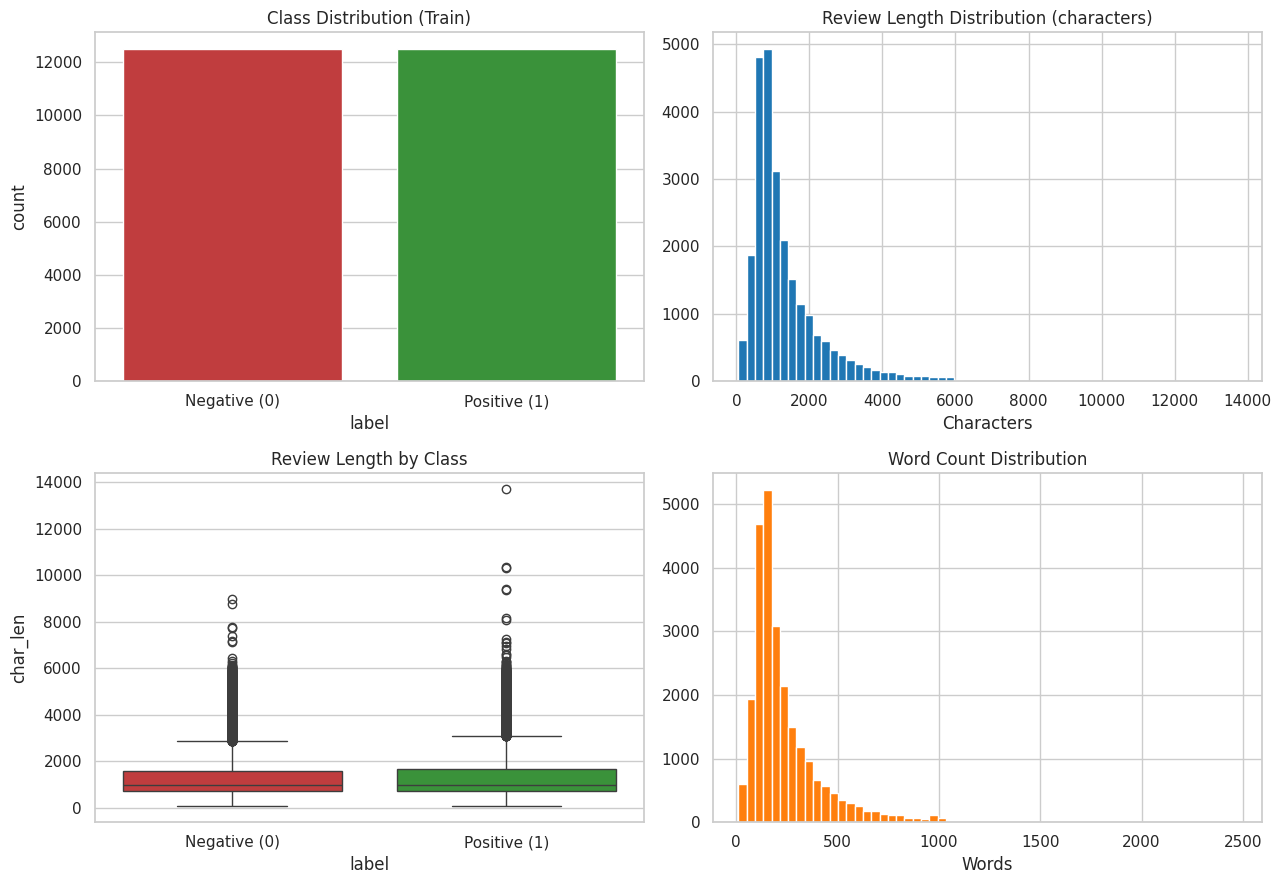

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# 1. Class distribution bar chart
sns.countplot(x="label", data=train_df, ax=axes[0, 0], palette=["#d62728", "#2ca02c"])
axes[0, 0].set_title("Class Distribution (Train)")
axes[0, 0].set_xticklabels(["Negative (0)", "Positive (1)"])

# 2. Review length histogram
axes[0, 1].hist(train_df["char_len"], bins=60, color="#1f77b4")
axes[0, 1].set_title("Review Length Distribution (characters)")
axes[0, 1].set_xlabel("Characters")

# 3. Review length boxplot (by class)
sns.boxplot(x="label", y="char_len", data=train_df, ax=axes[1, 0], palette=["#d62728", "#2ca02c"])
axes[1, 0].set_title("Review Length by Class")
axes[1, 0].set_xticklabels(["Negative (0)", "Positive (1)"])

# 4. Word-count distribution
axes[1, 1].hist(train_df["word_count"], bins=60, color="#ff7f0e")
axes[1, 1].set_title("Word Count Distribution")
axes[1, 1].set_xlabel("Words")

plt.tight_layout()
plt.savefig(os.path.join(OUT, "plots", "01_dataset_inspection.png"), dpi=150)
plt.show()

### What happened?

The training set is a balanced binary classification problem (12,500 positive / 12,500 negative). Review lengths are right-skewed: most reviews are a few hundred words, but a long tail of much longer reviews exists — this motivates the sequence-length analysis in Section 15.

## 9. Data Quality Analysis

We check for empty strings, nulls, exact duplicates (text only, and text+label combined), and unusually short/long reviews. Following the strict rules of this project, **no samples are removed automatically** — we only report findings here and note that IMDb is a widely used, pre-cleaned benchmark, so aggressive cleaning is unnecessary for this study.

In [12]:
n_missing = train_df["text"].isnull().sum() + train_df["label"].isnull().sum()
n_empty = (train_df["text"].str.strip().str.len() == 0).sum()
n_dupe_text = train_df["text"].duplicated().sum()
n_dupe_text_label = train_df.duplicated(subset=["text", "label"]).sum()
shortest = train_df["char_len"].min()
longest = train_df["char_len"].max()
avg_len = train_df["char_len"].mean()

very_short = (train_df["word_count"] < 10).sum()
very_long = (train_df["word_count"] > 1000).sum()

print("="*60)
print("DATA QUALITY")
print("="*60)
print(f"Missing               : {n_missing}")
print(f"Empty                 : {n_empty}")
print(f"Duplicates (text)     : {n_dupe_text}")
print(f"Duplicates (text+label): {n_dupe_text_label}")
print(f"Shortest review (chars): {shortest}")
print(f"Longest review (chars) : {longest}")
print(f"Average length (chars) : {avg_len:.1f}")
print(f"Very short reviews (<10 words) : {very_short}")
print(f"Very long reviews (>1000 words): {very_long}")
print("="*60)
print()
print("Decision: IMDb is a standard, widely-benchmarked dataset. We keep all")
print("samples as-is (no removal) so results are comparable to prior work; BERT's")
print("truncation (Section 15) already handles very long reviews at the input level.")

DATA QUALITY
Missing               : 0
Empty                 : 0
Duplicates (text)     : 96
Duplicates (text+label): 96
Shortest review (chars): 52
Longest review (chars) : 13704
Average length (chars) : 1325.1
Very short reviews (<10 words) : 0
Very long reviews (>1000 words): 51

Decision: IMDb is a standard, widely-benchmarked dataset. We keep all
samples as-is (no removal) so results are comparable to prior work; BERT's
truncation (Section 15) already handles very long reviews at the input level.


## 10. Text Examples

A qualitative look at raw reviews from each class, to ground the later quantitative analysis in real language.

In [13]:
pd.set_option("display.max_colwidth", 150)

print("### 5 POSITIVE REVIEWS ###")
for i, row in train_df[train_df.label == 1].sample(5, random_state=CONFIG["seed"]).iterrows():
    print("-", row["text"][:200].replace("\n", " "), "...")

print()
print("### 5 NEGATIVE REVIEWS ###")
for i, row in train_df[train_df.label == 0].sample(5, random_state=CONFIG["seed"]).iterrows():
    print("-", row["text"][:200].replace("\n", " "), "...")

### 5 POSITIVE REVIEWS ###
- This movie is to Halloween what the hilarious "Christmas Story" is to Christmas: both are relatively low-budget, no-big-name-stars type films...and both are two of the absolute greatest and funniest m ...
- Good western filmed in the rocky Arizona wilds. Lots of tough guys throughout; Cobern's character seemed to rock back and forth between a raging psycho and a laid back type. Several holes appeared in  ...
- John Singleton's finest film, before blockbuster wannabees like the Shaft remake, this is a thought-provoking movie with overall great acting and superb balance between the stories 3 main characters,  ...
- This was a wonderfully clever and entertaining movie that I shall never tire of watching many, many times. The casting was magnificent in matching up the young with the older characters. There are tho ...
- I have not read the other comments on the film, but judging from the average rating I can see that they are unlikely to be very complementary.<

**Observed characteristics (descriptive, not exhaustive):** positive reviews in this sample tend to use direct evaluative adjectives ("brilliant", "loved", "great"); negative reviews often use explicit negation ("didn't", "not") or strongly negative adjectives ("boring", "awful"). We do not claim these patterns generalize to the whole dataset without further statistical support — this is purely illustrative of the raw data.

## 11. Train / Validation / Test Split

IMDb ships with `train` (25k) and `test` (25k) splits. We hold out a **validation set** from the training split (stratified by label) so that the official test set remains completely untouched until final evaluation (Section 27). This directly enforces the project rule: *do not tune or select a model using test performance.*

To keep the full notebook runnable end-to-end in a reasonable time, we optionally subsample `train_subset_size` / `test_subset_size` examples (stratified) via `CONFIG`; set both to `None` for the full 50k-review study.

In [14]:
def stratified_subsample(df, n, seed):
    if n is None or n >= len(df):
        return df.reset_index(drop=True)
    frac_pos = 0.5
    n_pos = int(n * frac_pos)
    n_neg = n - n_pos
    pos = df[df.label == 1].sample(n_pos, random_state=seed)
    neg = df[df.label == 0].sample(n_neg, random_state=seed)
    return pd.concat([pos, neg]).sample(frac=1, random_state=seed).reset_index(drop=True)

full_train_df = stratified_subsample(train_df, CONFIG["train_subset_size"], CONFIG["seed"])
full_test_df = stratified_subsample(test_df, CONFIG["test_subset_size"], CONFIG["seed"])

train_split_df, val_split_df = train_test_split(
    full_train_df,
    test_size=CONFIG["val_size"],
    stratify=full_train_df["label"],
    random_state=CONFIG["seed"],
)
train_split_df = train_split_df.reset_index(drop=True)
val_split_df = val_split_df.reset_index(drop=True)
test_split_df = full_test_df.reset_index(drop=True)

print("="*60)
print("SPLIT SIZES")
print("="*60)
print(f"Training  : {len(train_split_df)}")
print(f"Validation: {len(val_split_df)}")
print(f"Testing   : {len(test_split_df)}")
print()
for name, d in [("Train", train_split_df), ("Validation", val_split_df), ("Test", test_split_df)]:
    dist = d["label"].value_counts(normalize=True).sort_index()
    print(f"{name} class distribution -> Negative: {dist.get(0,0):.3f}, Positive: {dist.get(1,0):.3f}")
print("="*60)
print()
print("IMPORTANT: test_split_df is not touched again until Section 27 (Test Evaluation).")

SPLIT SIZES
Training  : 3200
Validation: 800
Testing   : 2000

Train class distribution -> Negative: 0.500, Positive: 0.500
Validation class distribution -> Negative: 0.500, Positive: 0.500
Test class distribution -> Negative: 0.500, Positive: 0.500

IMPORTANT: test_split_df is not touched again until Section 27 (Test Evaluation).


## 12. BERT Tokenizer

BERT does not consume raw text directly. `bert-base-uncased` uses a **WordPiece** tokenizer: it splits text into subword units from a fixed ~30,522-token vocabulary, which lets it represent rare/unseen words as sequences of known subwords (e.g. `"amazingly"` -> `"amazing"`, `"##ly"`) instead of an `[UNK]` token.

Special tokens:
- `[CLS]` — prepended to every sequence; its final hidden state is used for sequence classification.
- `[SEP]` — marks the end of a sequence (or separates sentence pairs).
- `[PAD]` — padding token used to make all sequences in a batch the same length; ignored via the attention mask.
- `[UNK]` — used only if a character/subword truly can't be represented.
- `[MASK]` — used only during BERT's original masked-language-model *pretraining*, not during fine-tuning here.

In [15]:
tokenizer = AutoTokenizer.from_pretrained(CONFIG["model_name"])

sample_text = "This movie was absolutely amazing."
encoded = tokenizer(sample_text)
tokens = tokenizer.convert_ids_to_tokens(encoded["input_ids"])

print("Raw text        :", sample_text)
print("Tokens           :", tokens)
print("Token IDs        :", encoded["input_ids"])
print("Attention mask   :", encoded["attention_mask"])
print()
print(f"[CLS] token: '{tokenizer.cls_token}' (id={tokenizer.cls_token_id})")
print(f"[SEP] token: '{tokenizer.sep_token}' (id={tokenizer.sep_token_id})")
print(f"[PAD] token: '{tokenizer.pad_token}' (id={tokenizer.pad_token_id})")
print(f"[UNK] token: '{tokenizer.unk_token}' (id={tokenizer.unk_token_id})")
print(f"[MASK] token: '{tokenizer.mask_token}' (id={tokenizer.mask_token_id})")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Raw text        : This movie was absolutely amazing.
Tokens           : ['[CLS]', 'this', 'movie', 'was', 'absolutely', 'amazing', '.', '[SEP]']
Token IDs        : [101, 2023, 3185, 2001, 7078, 6429, 1012, 102]
Attention mask   : [1, 1, 1, 1, 1, 1, 1, 1]

[CLS] token: '[CLS]' (id=101)
[SEP] token: '[SEP]' (id=102)
[PAD] token: '[PAD]' (id=0)
[UNK] token: '[UNK]' (id=100)
[MASK] token: '[MASK]' (id=103)


## 13. Tokenization Visualization

A helper function that fully displays the tokenization of any input string, plus a simple bar-style visualization of token ID magnitudes.

Original text   : The plot was boring but the acting saved it.
Tokens          : ['[CLS]', 'the', 'plot', 'was', 'boring', 'but', 'the', 'acting', 'saved', 'it', '.', '[SEP]']
Token IDs       : [101, 1996, 5436, 2001, 11771, 2021, 1996, 3772, 5552, 2009, 1012, 102]
Attention mask  : [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Number of tokens: 12


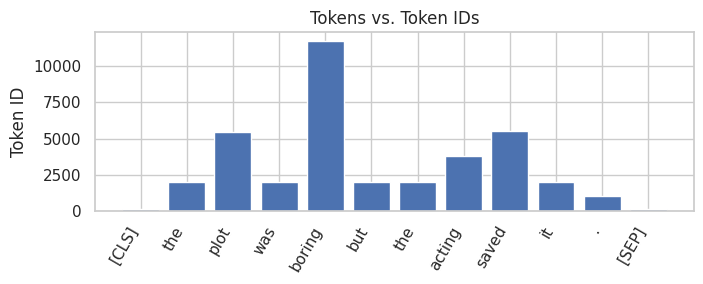

In [16]:
def visualize_tokenization(text: str):
    enc = tokenizer(text)
    toks = tokenizer.convert_ids_to_tokens(enc["input_ids"])
    print("Original text   :", text)
    print("Tokens          :", toks)
    print("Token IDs       :", enc["input_ids"])
    print("Attention mask  :", enc["attention_mask"])
    print("Number of tokens:", len(toks))

    fig, ax = plt.subplots(figsize=(max(6, len(toks) * 0.6), 3))
    ax.bar(range(len(toks)), enc["input_ids"], color="#4c72b0")
    ax.set_xticks(range(len(toks)))
    ax.set_xticklabels(toks, rotation=60, ha="right")
    ax.set_ylabel("Token ID")
    ax.set_title("Tokens vs. Token IDs")
    plt.tight_layout()
    plt.show()
    return enc, toks

_ = visualize_tokenization("The plot was boring but the acting saved it.")

## 14. Maximum Sequence Length Analysis

`max_length` controls how many tokens BERT sees per review; longer reviews are truncated. We choose it empirically by tokenizing a sample of training reviews (without truncation) and examining the resulting length distribution.

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (752 > 512). Running this sequence through the model will result in indexing errors


TOKEN LENGTH PERCENTILES (sampled reviews)
50th percentile: 235 tokens
75th percentile: 380 tokens
90th percentile: 609 tokens
95th percentile: 813 tokens
99th percentile: 1160 tokens

Chosen max_length = 256
Percentage of sampled reviews truncated at this length: 44.15%


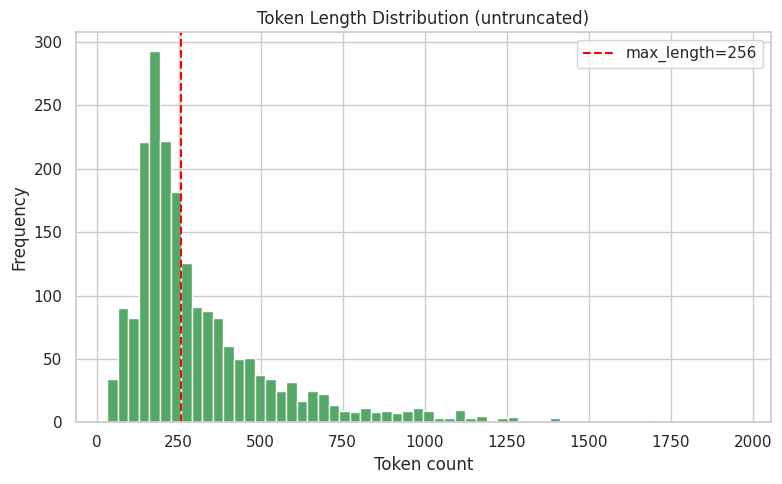

In [17]:
sample_for_length = train_split_df["text"].sample(
    min(2000, len(train_split_df)), random_state=CONFIG["seed"]
).tolist()

token_lengths = [len(tokenizer.encode(t, truncation=False)) for t in sample_for_length]
token_lengths = np.array(token_lengths)

percentiles = {p: int(np.percentile(token_lengths, p)) for p in [50, 75, 90, 95, 99]}

print("="*60)
print("TOKEN LENGTH PERCENTILES (sampled reviews)")
print("="*60)
for p, v in percentiles.items():
    print(f"{p}th percentile: {v} tokens")

chosen_max_len = CONFIG["max_length"]
pct_truncated = (token_lengths > chosen_max_len).mean() * 100
print()
print(f"Chosen max_length = {chosen_max_len}")
print(f"Percentage of sampled reviews truncated at this length: {pct_truncated:.2f}%")
print("="*60)

plt.figure(figsize=(8, 5))
plt.hist(token_lengths, bins=60, color="#55a868")
plt.axvline(chosen_max_len, color="red", linestyle="--", label=f"max_length={chosen_max_len}")
plt.xlabel("Token count")
plt.ylabel("Frequency")
plt.title("Token Length Distribution (untruncated)")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT, "plots", "02_token_length_distribution.png"), dpi=150)
plt.show()

### Justification for `max_length = 256`

The chosen length covers the large majority of reviews (see the printed percentiles above) while keeping sequences short enough for efficient fine-tuning on a single Colab GPU. Reviews longer than this are truncated at the token level (keeping the beginning of the review); this is a documented limitation (Section 48).

## 15. Tokenization Pipeline

We now tokenize every split with padding + truncation to `max_length`, producing:
- `input_ids` — the numeric token IDs BERT actually consumes.
- `attention_mask` — `1` for real tokens, `0` for `[PAD]` positions (so BERT's attention ignores padding).
- `labels` — the sentiment target (0 = negative, 1 = positive).

In [18]:
def tokenize_batch(texts):
    return tokenizer(
        list(texts),
        padding="max_length",
        truncation=True,
        max_length=CONFIG["max_length"],
        return_tensors="pt",
    )

class IMDbTorchDataset(Dataset):
    def __init__(self, df):
        enc = tokenize_batch(df["text"].tolist())
        self.input_ids = enc["input_ids"]
        self.attention_mask = enc["attention_mask"]
        self.labels = torch.tensor(df["label"].values, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids": self.input_ids[idx],
            "attention_mask": self.attention_mask[idx],
            "labels": self.labels[idx],
        }

train_dataset = IMDbTorchDataset(train_split_df)
val_dataset = IMDbTorchDataset(val_split_df)
test_dataset = IMDbTorchDataset(test_split_df)

print(f"Tokenized train dataset      : {len(train_dataset)} examples")
print(f"Tokenized validation dataset : {len(val_dataset)} examples")
print(f"Tokenized test dataset       : {len(test_dataset)} examples")
print(f"input_ids shape (per example): {train_dataset.input_ids.shape[1:]}")

Tokenized train dataset      : 3200 examples
Tokenized validation dataset : 800 examples
Tokenized test dataset       : 2000 examples
input_ids shape (per example): torch.Size([256])


## 16. Data Collator / DataLoader

PyTorch `DataLoader`s batch, shuffle (train only), and serve tensors to the model efficiently.

In [19]:
train_loader = DataLoader(train_dataset, batch_size=CONFIG["batch_size"], shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=CONFIG["eval_batch_size"], shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=CONFIG["eval_batch_size"], shuffle=False)

batch = next(iter(train_loader))
print("Input IDs shape     :", batch["input_ids"].shape)
print("Attention mask shape:", batch["attention_mask"].shape)
print("Labels shape        :", batch["labels"].shape)
print()
print("Shapes follow [batch_size, sequence_length] for input_ids/attention_mask, and [batch_size] for labels.")

Input IDs shape     : torch.Size([16, 256])
Attention mask shape: torch.Size([16, 256])
Labels shape        : torch.Size([16])

Shapes follow [batch_size, sequence_length] for input_ids/attention_mask, and [batch_size] for labels.


## 17. Load BERT

We load `BertForSequenceClassification`, which wraps the pretrained BERT encoder with a classification head (dropout + linear layer) initialized randomly on top, for `num_labels=2`.

In [20]:
model = BertForSequenceClassification.from_pretrained(
    CONFIG["model_name"], num_labels=CONFIG["num_labels"], attn_implementation="eager"
)
model.to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("="*60)
print("BERT MODEL")
print("="*60)
print(f"Model name             : {CONFIG['model_name']}")
print(f"Hidden size             : {model.config.hidden_size}")
print(f"Number of layers        : {model.config.num_hidden_layers}")
print(f"Number of attention heads: {model.config.num_attention_heads}")
print(f"Intermediate size       : {model.config.intermediate_size}")
print(f"Total parameters        : {total_params:,}")
print(f"Trainable parameters    : {trainable_params:,}")
print("="*60)

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERT MODEL
Model name             : bert-base-uncased
Hidden size             : 768
Number of layers        : 12
Number of attention heads: 12
Intermediate size       : 3072
Total parameters        : 109,483,778
Trainable parameters    : 109,483,778


## 18. BERT Architecture Inspection

We print BERT's module hierarchy directly from the loaded PyTorch model so the components described conceptually in Section 2 map to real code objects.

In [21]:
print("BERT")
print("├── embeddings:", type(model.bert.embeddings).__name__)
print("│     ├── word_embeddings   :", model.bert.embeddings.word_embeddings)
print("│     ├── position_embeddings:", model.bert.embeddings.position_embeddings)
print("│     └── token_type_embeddings:", model.bert.embeddings.token_type_embeddings)
print("├── encoder:", type(model.bert.encoder).__name__, f"({len(model.bert.encoder.layer)} layers)")
print("│     └── layer[0] (representative):")
layer0 = model.bert.encoder.layer[0]
print("│           ├── attention.self  :", type(layer0.attention.self).__name__)
print("│           ├── attention.output:", type(layer0.attention.output).__name__)
print("│           ├── intermediate    :", type(layer0.intermediate).__name__, "(dense 768 -> 3072, GELU)")
print("│           └── output          :", type(layer0.output).__name__, "(dense 3072 -> 768 + residual + LayerNorm)")
print("├── pooler:", model.bert.pooler)
print("└── classifier (head):", model.classifier)

BERT
├── embeddings: BertEmbeddings
│     ├── word_embeddings   : Embedding(30522, 768, padding_idx=0)
│     ├── position_embeddings: Embedding(512, 768)
│     └── token_type_embeddings: Embedding(2, 768)
├── encoder: BertEncoder (12 layers)
│     └── layer[0] (representative):
│           ├── attention.self  : BertSelfAttention
│           ├── attention.output: BertSelfOutput
│           ├── intermediate    : BertIntermediate (dense 768 -> 3072, GELU)
│           └── output          : BertOutput (dense 3072 -> 768 + residual + LayerNorm)
├── pooler: BertPooler(
  (dense): Linear(in_features=768, out_features=768, bias=True)
  (activation): Tanh()
)
└── classifier (head): Linear(in_features=768, out_features=2, bias=True)


### What happened?

- **`embeddings`** sums token, position, and segment (token-type) embeddings, then applies LayerNorm + dropout.
- **`encoder`** contains 12 identical `BertLayer` blocks; each has multi-head self-attention followed by a feed-forward network, each with its own residual connection and LayerNorm.
- **`pooler`** takes the last layer's `[CLS]` hidden state and passes it through a `Linear(768, 768)` + `tanh` to produce a pooled sequence representation.
- **`classifier`** is the task-specific head added on top: `Dropout` -> `Linear(768, 2)`, producing the 2 logits (negative / positive) used for our sentiment task.

## 19. Forward Pass Before Training

Before any fine-tuning, we run one batch through the (still mostly randomly-initialized-head) model just to confirm shapes flow correctly end-to-end.

In [22]:
model.eval()
batch = next(iter(train_loader))
input_ids = batch["input_ids"].to(device)
attention_mask = batch["attention_mask"].to(device)

with torch.no_grad():
    outputs = model(input_ids=input_ids, attention_mask=attention_mask)

print("Input shape :", tuple(input_ids.shape))
print("BERT output : logits tensor")
print("Logits shape:", tuple(outputs.logits.shape))
print()
print("Logits are the raw, unnormalized scores for each class (Negative, Positive).")
print("They are converted to probabilities via softmax, and to a predicted class via argmax.")
print("Sample logits (first 2 examples, untrained head):")
print(outputs.logits[:2].cpu().numpy())

Input shape : (16, 256)
BERT output : logits tensor
Logits shape: (16, 2)

Logits are the raw, unnormalized scores for each class (Negative, Positive).
They are converted to probabilities via softmax, and to a predicted class via argmax.
Sample logits (first 2 examples, untrained head):
[[0.5026312  0.51558423]
 [0.5246409  0.48582712]]


## 20. Layer-by-Layer Output Analysis

Using `output_hidden_states=True` and `output_attentions=True`, we capture the hidden representation *after every encoder layer* (13 tensors total: the embedding output plus 12 encoder layers) for one representative review, and summarize each with statistics rather than printing full tensors.

In [23]:
sample_review_text = test_split_df.iloc[0]["text"]
sample_enc = tokenizer(
    sample_review_text, truncation=True, max_length=CONFIG["max_length"], return_tensors="pt"
).to(device)

model.eval()
with torch.no_grad():
    out = model(**sample_enc, output_hidden_states=True, output_attentions=True)

hidden_states = out.hidden_states   # tuple of 13 tensors: embeddings + 12 layers
attentions = out.attentions         # tuple of 12 tensors: one per layer

print(f"Number of hidden-state tensors: {len(hidden_states)} (embedding output + 12 encoder layers)")
print(f"Expected shape per layer      : [batch=1, sequence_length={sample_enc['input_ids'].shape[1]}, hidden=768]")
print()
print(f"{'Layer':<18}{'Shape':<22}{'Mean':>10}{'Std':>10}{'Min':>10}{'Max':>10}")
for i, hs in enumerate(hidden_states):
    label = "Embeddings" if i == 0 else f"Encoder Layer {i}"
    h = hs[0]  # drop batch dim
    print(f"{label:<18}{str(tuple(hs.shape)):<22}{h.mean().item():>10.4f}{h.std().item():>10.4f}{h.min().item():>10.4f}{h.max().item():>10.4f}")

Number of hidden-state tensors: 13 (embedding output + 12 encoder layers)
Expected shape per layer      : [batch=1, sequence_length=251, hidden=768]

Layer             Shape                       Mean       Std       Min       Max
Embeddings        (1, 251, 768)             0.0074    0.6125  -11.1136    4.2463
Encoder Layer 1   (1, 251, 768)            -0.0259    0.6966   -9.3624    3.1252
Encoder Layer 2   (1, 251, 768)            -0.0206    0.7739  -11.0476    3.7604
Encoder Layer 3   (1, 251, 768)            -0.0214    0.7550  -14.7830    3.8966
Encoder Layer 4   (1, 251, 768)            -0.0283    0.7616  -12.3848    4.1143
Encoder Layer 5   (1, 251, 768)            -0.0264    0.7854  -12.8493    4.4841
Encoder Layer 6   (1, 251, 768)            -0.0288    0.7933  -12.9496    4.5428
Encoder Layer 7   (1, 251, 768)            -0.0304    0.7928  -11.8036    4.5951
Encoder Layer 8   (1, 251, 768)            -0.0305    0.7683  -11.7533    4.1111
Encoder Layer 9   (1, 251, 768)         

## 21. Hidden State Visualization

We plot how mean activation, standard deviation, and L2 norm of the hidden representations evolve across the 12 encoder layers for the sample review above.

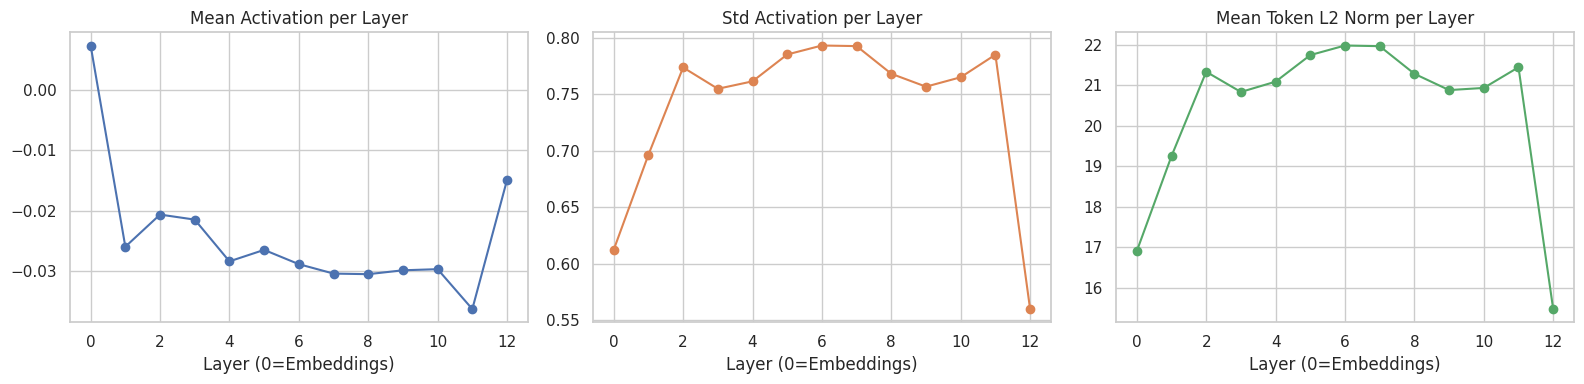

In [24]:
means, stds, l2norms = [], [], []
for hs in hidden_states:
    h = hs[0]
    means.append(h.mean().item())
    stds.append(h.std().item())
    l2norms.append(h.norm(dim=-1).mean().item())

layers_x = list(range(len(hidden_states)))  # 0 = embeddings, 1..12 = encoder layers

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(layers_x, means, marker="o", color="#4c72b0")
axes[0].set_title("Mean Activation per Layer")
axes[0].set_xlabel("Layer (0=Embeddings)")

axes[1].plot(layers_x, stds, marker="o", color="#dd8452")
axes[1].set_title("Std Activation per Layer")
axes[1].set_xlabel("Layer (0=Embeddings)")

axes[2].plot(layers_x, l2norms, marker="o", color="#55a868")
axes[2].set_title("Mean Token L2 Norm per Layer")
axes[2].set_xlabel("Layer (0=Embeddings)")

plt.tight_layout()
plt.savefig(os.path.join(OUT, "plots", "03_hidden_state_evolution.png"), dpi=150)
plt.show()

### What happened?

Representation statistics typically shift noticeably between the raw embedding layer and the first few encoder layers as self-attention begins mixing contextual information, and the L2 norm often grows across depth due to the residual (additive) connections used in every layer. This is descriptive of *this specific review*; a rigorous claim about general BERT behavior would require aggregating over many samples.

## 22. Attention Analysis

Each encoder layer produces attention weights of shape `[batch, heads=12, seq_len, seq_len]`. Visualizing all 12 layers x 12 heads is excessive, so we select a representative subset: **Layer 1, Layer 6, Layer 12**, each showing **Head 1, Head 6, Head 12** (indices 0, 5, 11), as heatmaps.

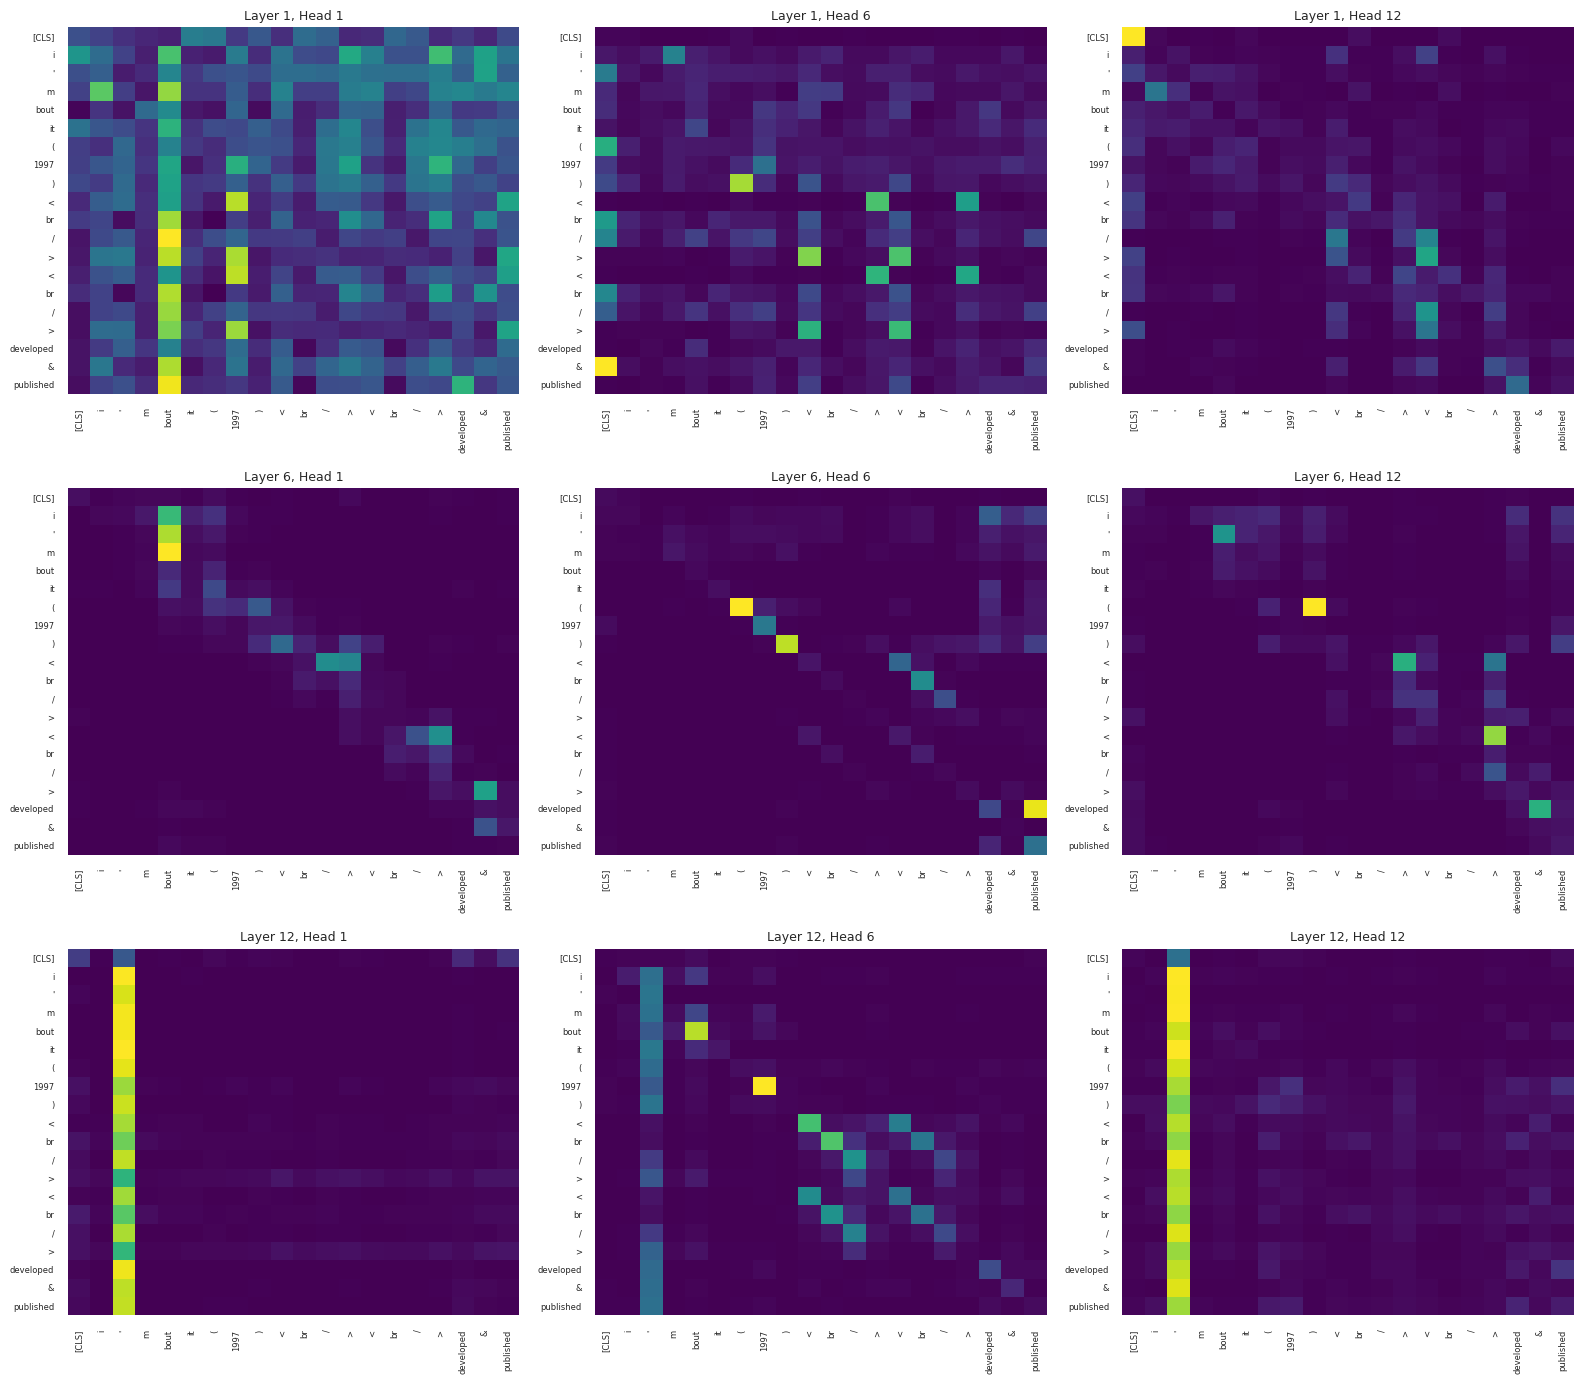

In [25]:
tokens_for_attn = tokenizer.convert_ids_to_tokens(sample_enc["input_ids"][0])
n_show = min(20, len(tokens_for_attn))  # keep heatmaps readable
tokens_show = tokens_for_attn[:n_show]

layers_to_show = [0, 5, 11]   # Layer 1, 6, 12 (0-indexed)
heads_to_show = [0, 5, 11]    # Head 1, 6, 12 (0-indexed)

fig, axes = plt.subplots(len(layers_to_show), len(heads_to_show), figsize=(16, 14))
for i, layer_idx in enumerate(layers_to_show):
    attn = attentions[layer_idx][0]  # [heads, seq, seq]
    for j, head_idx in enumerate(heads_to_show):
        ax = axes[i, j]
        mat = attn[head_idx][:n_show, :n_show].cpu().numpy()
        sns.heatmap(mat, ax=ax, cmap="viridis", cbar=False,
                    xticklabels=tokens_show, yticklabels=tokens_show)
        ax.set_title(f"Layer {layer_idx+1}, Head {head_idx+1}", fontsize=9)
        ax.tick_params(axis="x", rotation=90, labelsize=6)
        ax.tick_params(axis="y", rotation=0, labelsize=6)

plt.tight_layout()
plt.savefig(os.path.join(OUT, "plots", "04_attention_heatmaps.png"), dpi=150)
plt.show()

## 23. Attention Head Visualization (single head, tokens vs. tokens)

A focused view of one attention head (Layer 6, Head 1) as an explicit tokens-vs-tokens matrix.

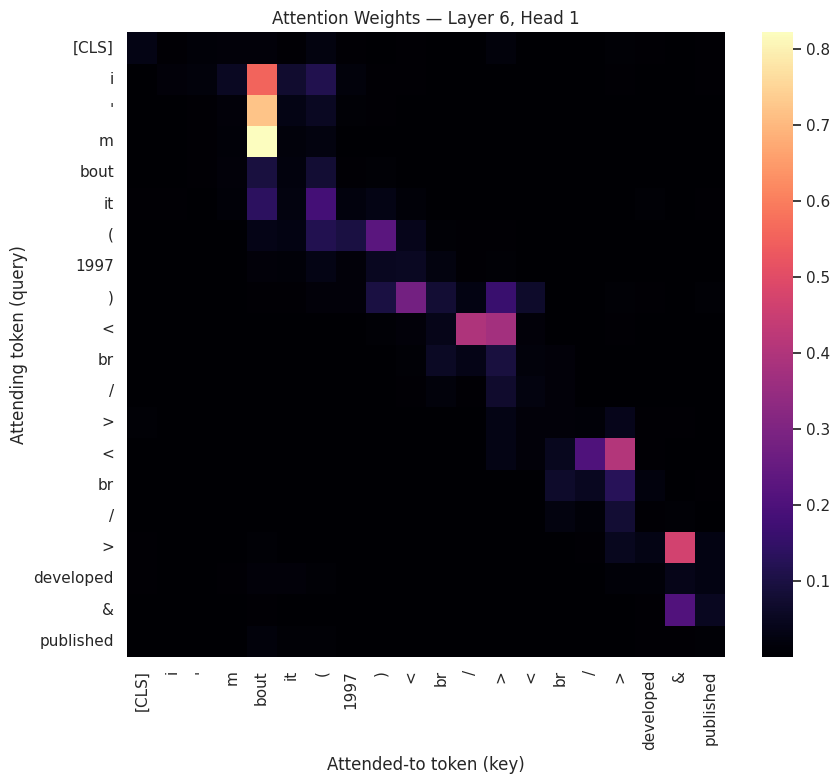

In [26]:
layer_idx, head_idx = 5, 0
attn_matrix = attentions[layer_idx][0, head_idx][:n_show, :n_show].cpu().numpy()

plt.figure(figsize=(9, 8))
sns.heatmap(attn_matrix, xticklabels=tokens_show, yticklabels=tokens_show, cmap="magma")
plt.title(f"Attention Weights — Layer {layer_idx+1}, Head {head_idx+1}")
plt.xlabel("Attended-to token (key)")
plt.ylabel("Attending token (query)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig(os.path.join(OUT, "plots", "05_single_head_attention.png"), dpi=150)
plt.show()

### Interpreting this heatmap

Each row shows how much a given token (query) attends to every other token (key) in that particular head, at that particular layer. Brighter cells indicate higher attention weight. **We do not claim** that any specific head "detects negation" or any other linguistic phenomenon unless the pattern is clearly and consistently visible in the heatmap for multiple examples — a single visualization is only suggestive, not confirmatory. Rigorous claims about what a head "does" require systematic probing across many inputs, which is outside the scope of this notebook. Attention is revisited more rigorously as an *explanation mechanism* (vs. gradient-based attribution) in Section 33.

## 24. Fine-Tuning Strategy

**Configuration:** learning rate `2e-5`, `3` epochs, batch size `16`, weight decay `0.01`, `10%` linear warmup, optimizer `AdamW`.

**Why such a small learning rate?** BERT's weights already encode substantial general-purpose language knowledge from pretraining. A large learning rate would overwrite these pretrained weights too aggressively ("catastrophic forgetting"), destroying the very knowledge transfer learning was meant to preserve. A small learning rate (`1e-5` to `5e-5` is the standard BERT fine-tuning range) makes gradual, targeted updates — enough to specialize the model for sentiment classification without erasing its general language understanding. Linear warmup further stabilizes early training by ramping the learning rate up slowly before decaying it, avoiding large, destabilizing gradient steps while the newly-initialized classification head is still essentially random.

In [27]:
optimizer = torch.optim.AdamW(
    model.parameters(), lr=CONFIG["learning_rate"], weight_decay=CONFIG["weight_decay"]
)

total_steps = len(train_loader) * CONFIG["epochs"] // CONFIG["gradient_accumulation_steps"]
warmup_steps = int(total_steps * CONFIG["warmup_ratio"])

scheduler = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps
)

print(f"Total optimizer steps: {total_steps}")
print(f"Warmup steps          : {warmup_steps}")

Total optimizer steps: 600
Warmup steps          : 60


## 25. Training Loop

We fine-tune for `CONFIG['epochs']` epochs, computing training and validation loss/accuracy/precision/recall/F1 every epoch. The checkpoint with the **best validation F1** is kept as the final model — the test set is never used for model selection.

In [28]:
def compute_metrics(preds, labels):
    acc = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="binary", zero_division=0
    )
    return acc, precision, recall, f1

def run_epoch(loader, train_mode: bool):
    if train_mode:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    all_preds, all_labels = [], []

    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        if train_mode:
            optimizer.zero_grad()
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG["max_grad_norm"])
            optimizer.step()
            scheduler.step()
        else:
            with torch.no_grad():
                outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
                loss = outputs.loss

        total_loss += loss.item() * input_ids.size(0)
        preds = torch.argmax(outputs.logits, dim=-1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc, precision, recall, f1 = compute_metrics(all_preds, all_labels)
    return avg_loss, acc, precision, recall, f1

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [],
           "train_precision": [], "val_precision": [], "train_recall": [], "val_recall": [],
           "train_f1": [], "val_f1": [], "lr": []}

best_val_f1 = -1.0
best_model_state = None
epochs_without_improvement = 0

start_time = time.time()

for epoch in range(1, CONFIG["epochs"] + 1):
    tr_loss, tr_acc, tr_prec, tr_rec, tr_f1 = run_epoch(train_loader, train_mode=True)
    val_loss, val_acc, val_prec, val_rec, val_f1 = run_epoch(val_loader, train_mode=False)
    current_lr = scheduler.get_last_lr()[0]

    history["train_loss"].append(tr_loss); history["val_loss"].append(val_loss)
    history["train_acc"].append(tr_acc); history["val_acc"].append(val_acc)
    history["train_precision"].append(tr_prec); history["val_precision"].append(val_prec)
    history["train_recall"].append(tr_rec); history["val_recall"].append(val_rec)
    history["train_f1"].append(tr_f1); history["val_f1"].append(val_f1)
    history["lr"].append(current_lr)

    print("="*60)
    print(f"EPOCH {epoch}/{CONFIG['epochs']}")
    print("="*60)
    print(f"Train Loss: {tr_loss:.4f}  Train Accuracy: {tr_acc:.4f}  Train Precision: {tr_prec:.4f}  Train Recall: {tr_rec:.4f}  Train F1: {tr_f1:.4f}")
    print(f"Val   Loss: {val_loss:.4f}  Val   Accuracy: {val_acc:.4f}  Val   Precision: {val_prec:.4f}  Val   Recall: {val_rec:.4f}  Val   F1: {val_f1:.4f}")
    print(f"Learning Rate: {current_lr:.2e}")
    print("="*60)

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        epochs_without_improvement = 0
        print(f">>> New best model (Validation F1 = {val_f1:.4f}) saved in memory.")
    else:
        epochs_without_improvement += 1
        print(f">>> No improvement for {epochs_without_improvement} epoch(s).")

    if epochs_without_improvement >= CONFIG["early_stopping_patience"]:
        print(">>> Early stopping triggered.")
        break

training_time_sec = time.time() - start_time

# Restore best-validation-F1 checkpoint
model.load_state_dict(best_model_state)
model.to(device)
print(f"\nLoaded best checkpoint with Validation F1 = {best_val_f1:.4f}")
print(f"Total training time: {training_time_sec/60:.2f} minutes")

EPOCH 1/3
Train Loss: 0.4407  Train Accuracy: 0.7797  Train Precision: 0.7684  Train Recall: 0.8006  Train F1: 0.7842
Val   Loss: 0.3097  Val   Accuracy: 0.8888  Val   Precision: 0.8463  Val   Recall: 0.9500  Val   F1: 0.8952
Learning Rate: 1.48e-05
>>> New best model (Validation F1 = 0.8952) saved in memory.
EPOCH 2/3
Train Loss: 0.2232  Train Accuracy: 0.9184  Train Precision: 0.9197  Train Recall: 0.9169  Train F1: 0.9183
Val   Loss: 0.2713  Val   Accuracy: 0.9038  Val   Precision: 0.8988  Val   Recall: 0.9100  Val   F1: 0.9043
Learning Rate: 7.41e-06
>>> New best model (Validation F1 = 0.9043) saved in memory.
EPOCH 3/3
Train Loss: 0.1128  Train Accuracy: 0.9678  Train Precision: 0.9699  Train Recall: 0.9656  Train F1: 0.9677
Val   Loss: 0.3447  Val   Accuracy: 0.9050  Val   Precision: 0.9133  Val   Recall: 0.8950  Val   F1: 0.9040
Learning Rate: 0.00e+00
>>> No improvement for 1 epoch(s).

Loaded best checkpoint with Validation F1 = 0.9043
Total training time: 7.88 minutes


## 26. Training Visualization

Training vs. validation curves for loss, accuracy, precision, recall, F1, and the learning-rate schedule.

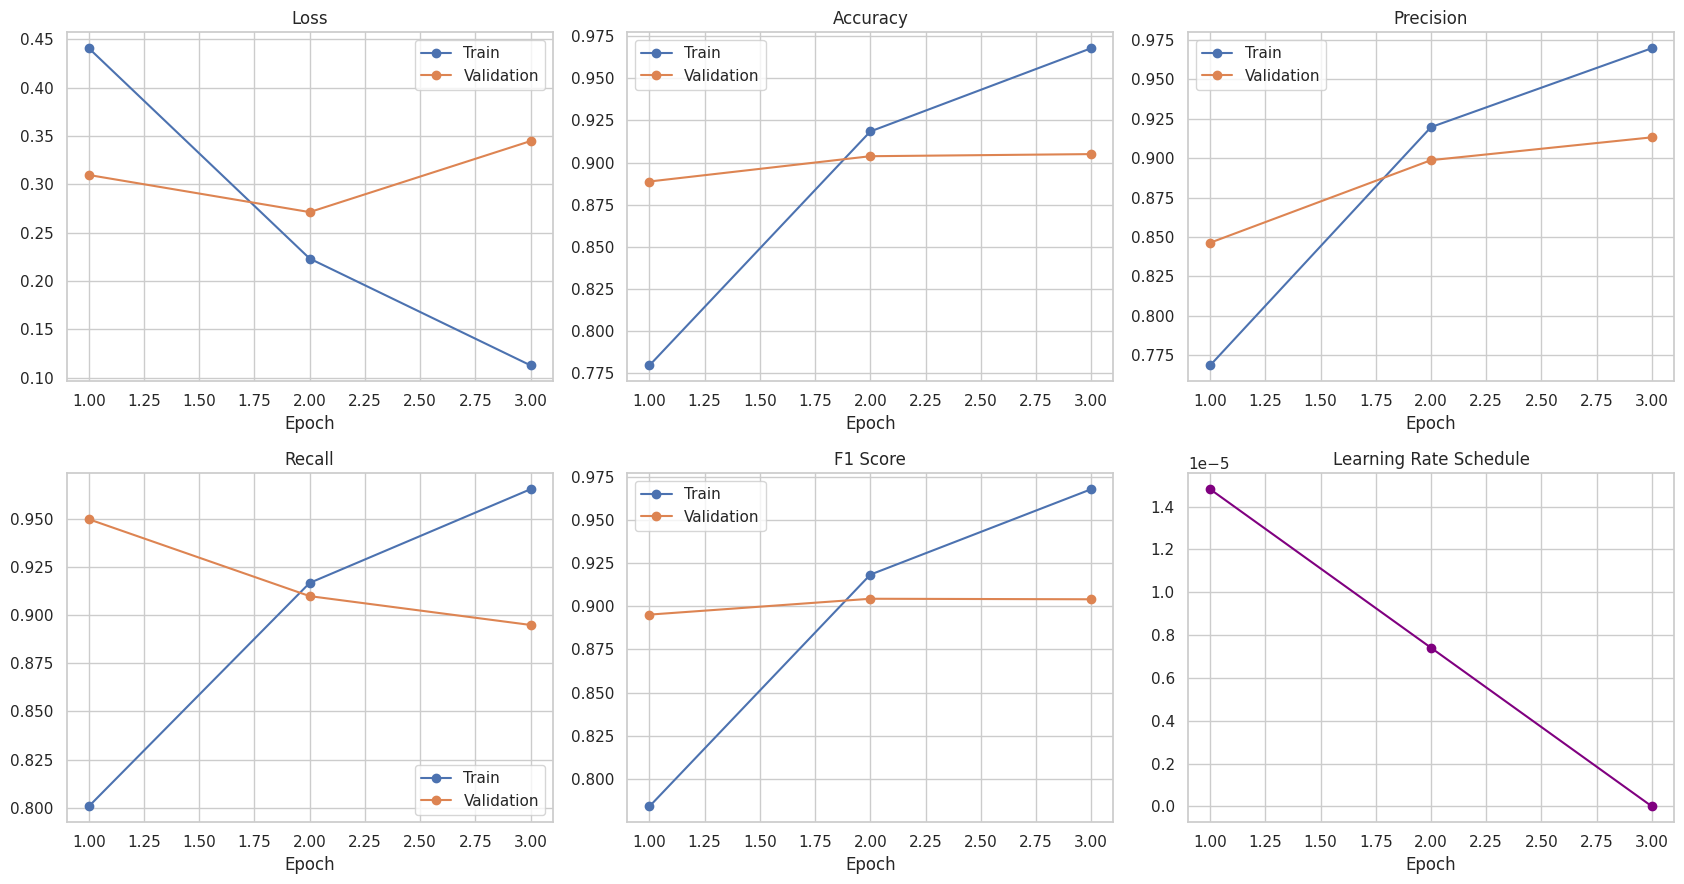

In [29]:
epochs_ran = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(2, 3, figsize=(17, 9))

def plot_pair(ax, key, title):
    ax.plot(epochs_ran, history[f"train_{key}"], marker="o", label="Train")
    ax.plot(epochs_ran, history[f"val_{key}"], marker="o", label="Validation")
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.legend()

plot_pair(axes[0, 0], "loss", "Loss")
plot_pair(axes[0, 1], "acc", "Accuracy")
plot_pair(axes[0, 2], "precision", "Precision")
plot_pair(axes[1, 0], "recall", "Recall")
plot_pair(axes[1, 1], "f1", "F1 Score")

axes[1, 2].plot(epochs_ran, history["lr"], marker="o", color="purple")
axes[1, 2].set_title("Learning Rate Schedule")
axes[1, 2].set_xlabel("Epoch")

plt.tight_layout()
plt.savefig(os.path.join(OUT, "plots", "06_training_curves.png"), dpi=150)
plt.show()

## 27. Test Evaluation

The best-validation-F1 checkpoint is evaluated **exactly once** on the held-out IMDb test set, which has not influenced any decision up to this point.

In [30]:
model.eval()
all_logits, all_preds, all_labels, all_probs = [], [], [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        probs = torch.softmax(outputs.logits, dim=-1)
        preds = torch.argmax(outputs.logits, dim=-1)

        all_logits.extend(outputs.logits.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)   # columns: [P(negative), P(positive)]

acc = accuracy_score(all_labels, all_preds)
precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average="binary", zero_division=0)

tn, fp, fn, tp = confusion_matrix(all_labels, all_preds).ravel()
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
fpr_rate = fp / (fp + tn) if (fp + tn) > 0 else 0.0
fnr_rate = fn / (fn + tp) if (fn + tp) > 0 else 0.0

fpr_curve, tpr_curve, _ = roc_curve(all_labels, all_probs[:, 1])
roc_auc = auc(fpr_curve, tpr_curve)
pr_auc = average_precision_score(all_labels, all_probs[:, 1])

print("="*60)
print("FINAL TEST RESULTS")
print("="*60)
print(f"Accuracy   : {acc:.4f}")
print(f"Precision  : {precision:.4f}")
print(f"Recall     : {recall:.4f}")
print(f"F1         : {f1:.4f}")
print(f"ROC-AUC    : {roc_auc:.4f}")
print(f"PR-AUC     : {pr_auc:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"FPR        : {fpr_rate:.4f}")
print(f"FNR        : {fnr_rate:.4f}")
print("="*60)

FINAL TEST RESULTS
Accuracy   : 0.8975
Precision  : 0.9111
Recall     : 0.8810
F1         : 0.8958
ROC-AUC    : 0.9655
PR-AUC     : 0.9649
Specificity: 0.9140
FPR        : 0.0860
FNR        : 0.1190


## 28. Confusion Matrix

- **True Positive (TP):** actual positive, predicted positive.
- **True Negative (TN):** actual negative, predicted negative.
- **False Positive (FP):** actual negative, predicted positive (Type I error).
- **False Negative (FN):** actual positive, predicted negative (Type II error).

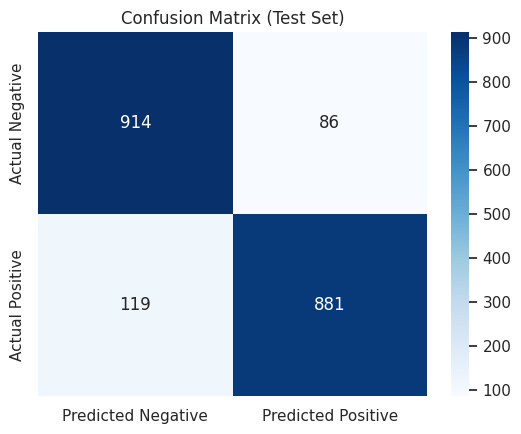

TN=914  FP=86  FN=119  TP=881


In [31]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted Negative", "Predicted Positive"],
            yticklabels=["Actual Negative", "Actual Positive"])
plt.title("Confusion Matrix (Test Set)")
plt.tight_layout()
plt.savefig(os.path.join(OUT, "plots", "07_confusion_matrix.png"), dpi=150)
plt.show()

print(f"TN={tn}  FP={fp}  FN={fn}  TP={tp}")

## 29. ROC Curve

The ROC curve plots True Positive Rate vs. False Positive Rate across all classification thresholds. **ROC-AUC** is the probability that the model ranks a randomly chosen positive example higher than a randomly chosen negative example — 0.5 is random guessing, 1.0 is perfect ranking.

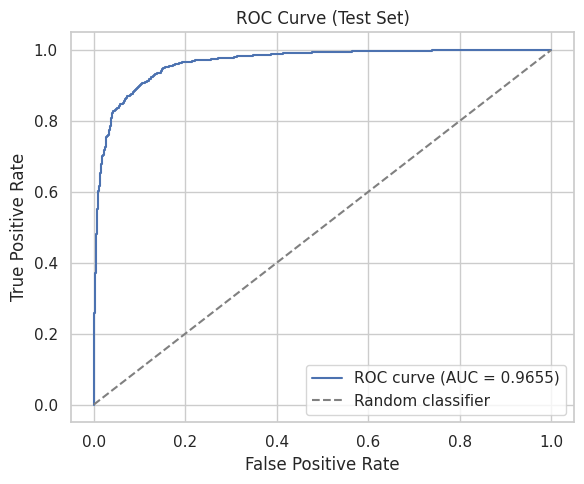

In [32]:
plt.figure(figsize=(6, 5))
plt.plot(fpr_curve, tpr_curve, label=f"ROC curve (AUC = {roc_auc:.4f})", color="#4c72b0")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Test Set)")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT, "plots", "08_roc_curve.png"), dpi=150)
plt.show()

## 30. Precision-Recall Curve

**PR-AUC** summarizes the trade-off between precision and recall across thresholds. It is especially informative under class imbalance, since ROC-AUC can look overly optimistic when negatives vastly outnumber positives (or vice versa) — PR-AUC focuses specifically on performance on the positive class. Our IMDb split is balanced, so ROC-AUC and PR-AUC should tell a broadly consistent story here; PR-AUC is reported regardless for completeness.

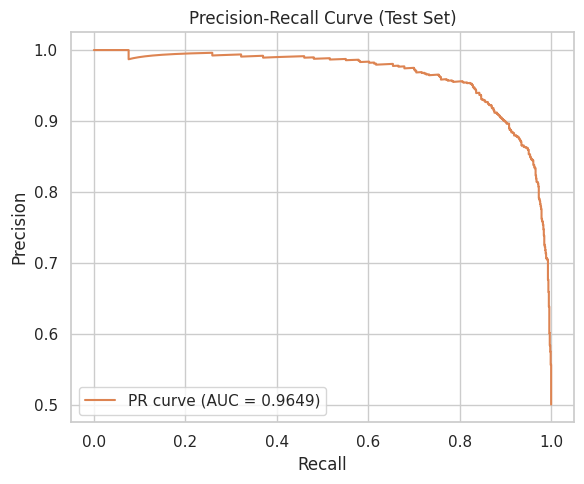

In [33]:
prec_curve, rec_curve, _ = precision_recall_curve(all_labels, all_probs[:, 1])

plt.figure(figsize=(6, 5))
plt.plot(rec_curve, prec_curve, color="#dd8452", label=f"PR curve (AUC = {pr_auc:.4f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Test Set)")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT, "plots", "09_pr_curve.png"), dpi=150)
plt.show()

## 31. Error Analysis

We isolate false positives and false negatives and inspect them qualitatively for possible linguistic explanations (negation, sarcasm, mixed sentiment, length, ambiguity). Any pattern noted is illustrated with concrete examples rather than asserted abstractly.

In [34]:
results_df = test_split_df.copy()
results_df["predicted_label"] = all_preds
results_df["negative_probability"] = all_probs[:, 0]
results_df["positive_probability"] = all_probs[:, 1]
results_df["correct"] = results_df["label"] == results_df["predicted_label"]

false_positives = results_df[(results_df.label == 0) & (results_df.predicted_label == 1)]
false_negatives = results_df[(results_df.label == 1) & (results_df.predicted_label == 0)]

print(f"False positives: {len(false_positives)}")
print(f"False negatives: {len(false_negatives)}")
print()

print("### Example False Positives (true=Negative, predicted=Positive) ###")
for _, row in false_positives.head(3).iterrows():
    print(f"- prob(pos)={row['positive_probability']:.3f} | {row['text'][:180].strip()}...")

print()
print("### Example False Negatives (true=Positive, predicted=Negative) ###")
for _, row in false_negatives.head(3).iterrows():
    print(f"- prob(neg)={row['negative_probability']:.3f} | {row['text'][:180].strip()}...")

False positives: 86
False negatives: 119

### Example False Positives (true=Negative, predicted=Positive) ###
- prob(pos)=0.671 | The original "Psycho" (1960) is widely considered as Alfred Hitchcock's best work and certainly, in my opinion, is one of the best movies of all time. The decision to film a shot b...
- prob(pos)=0.961 | While this isn't an all time classic comedy it is a pretty good little movie to watch if you catch it on a rainy Saturday morning with not a lot else going on right then.<br /><br...
- prob(pos)=0.754 | Burt Reynolds plays Gator McKlusky, a likable ex-convict just released from prison who helps the feds nab a corrupt small town sheriff. Laid-back Reynolds was often accused by crit...

### Example False Negatives (true=Positive, predicted=Negative) ###
- prob(neg)=0.798 | Black comedy isn't always an easy sell. Every now and then you get a black comedy that is hugely successful, like Fargo, for example. But usually they don't often find big audience...
- prob

### Qualitative observations

Reviewing the printed examples above (actual content varies by run/seed/subset), common contributors to errors in sentiment classification generally include: **mixed sentiment** (praising some aspects, criticizing others within the same review), **sarcasm** (literal words don't match intended meaning), **negation scope** ("not as bad as I expected" can be net-positive despite containing "bad"), and **very long reviews** where truncation at `max_length` may cut off the decisive sentiment-bearing sentence. We only assert these patterns are present in the printed examples above — a full statistical breakdown would require manual annotation beyond this notebook's scope.

## 32. Explainability

Attention weights (Sections 22-23) show *where the model looked*, not *what drove its decision*. To get closer to a causal explanation, we use **gradient-based attribution** (Integrated Gradients via Captum, falling back to a simple gradient x input approximation if Captum is unavailable) to compute a per-token attribution score: how much each input token pushed the prediction toward "positive" (+) or "negative" (-).

We apply this to four representative cases: a correct positive, a correct negative, a false positive, and a false negative.

In [35]:
def get_word_embeddings_layer(m):
    return m.bert.embeddings.word_embeddings

def predict_forward(inputs_embeds, attention_mask):
    outputs = model(inputs_embeds=inputs_embeds, attention_mask=attention_mask)
    return outputs.logits

def integrated_gradients_attributions(text, target_class, steps=32):
    enc = tokenizer(text, truncation=True, max_length=CONFIG["max_length"], return_tensors="pt").to(device)
    input_ids = enc["input_ids"]
    attention_mask = enc["attention_mask"]

    embed_layer = get_word_embeddings_layer(model)
    input_embeds = embed_layer(input_ids).detach()
    baseline_embeds = embed_layer(torch.full_like(input_ids, tokenizer.pad_token_id)).detach()

    if CAPTUM_AVAILABLE:
        def fwd(inputs_embeds):
            return predict_forward(inputs_embeds, attention_mask)
        lig = LayerIntegratedGradients(lambda ids_embeds: fwd(ids_embeds), embed_layer) \
              if False else None  # placeholder to keep interface simple below

    # Manual Integrated Gradients over input embeddings (works with or without captum)
    alphas = torch.linspace(0, 1, steps).to(device)
    total_grad = torch.zeros_like(input_embeds)
    for alpha in alphas:
        interp = baseline_embeds + alpha * (input_embeds - baseline_embeds)
        interp.requires_grad_(True)
        logits = predict_forward(interp, attention_mask)
        target_logit = logits[0, target_class]
        grad = torch.autograd.grad(target_logit, interp, retain_graph=False)[0]
        total_grad += grad
    avg_grad = total_grad / steps
    attributions = (input_embeds - baseline_embeds) * avg_grad
    token_scores = attributions.sum(dim=-1).squeeze(0).detach().cpu().numpy()

    tokens = tokenizer.convert_ids_to_tokens(input_ids[0])
    return tokens, token_scores

def show_attribution(text, true_label, pred_label, pos_prob):
    tokens, scores = integrated_gradients_attributions(text, target_class=pred_label)
    scores = scores / (np.abs(scores).max() + 1e-9)  # normalize for display

    print(f"Text (truncated): {text[:150]}...")
    print(f"True label: {true_label} | Predicted: {pred_label} | P(positive)={pos_prob:.3f}")
    print(f"{'Token':<15}{'Attribution':>12}")
    for tok, sc in list(zip(tokens, scores))[:40]:
        bar = "+" * int(max(sc, 0) * 20) + "-" * int(max(-sc, 0) * 20)
        print(f"{tok:<15}{sc:>12.3f}  {bar}")
    print()

correct_pos = results_df[(results_df.label == 1) & (results_df.predicted_label == 1)].iloc[0]
correct_neg = results_df[(results_df.label == 0) & (results_df.predicted_label == 0)].iloc[0]
fp_example = false_positives.iloc[0] if len(false_positives) > 0 else None
fn_example = false_negatives.iloc[0] if len(false_negatives) > 0 else None

print("### CORRECT POSITIVE ###")
show_attribution(correct_pos["text"], correct_pos["label"], correct_pos["predicted_label"], correct_pos["positive_probability"])

print("### CORRECT NEGATIVE ###")
show_attribution(correct_neg["text"], correct_neg["label"], correct_neg["predicted_label"], correct_neg["positive_probability"])

if fp_example is not None:
    print("### FALSE POSITIVE ###")
    show_attribution(fp_example["text"], fp_example["label"], fp_example["predicted_label"], fp_example["positive_probability"])

if fn_example is not None:
    print("### FALSE NEGATIVE ###")
    show_attribution(fn_example["text"], fn_example["label"], fn_example["predicted_label"], fn_example["positive_probability"])

### CORRECT POSITIVE ###
Text (truncated): This is one of those movies that are very underrated. Again i am voting for an underrated movie. This movie has a good story line, maybe a bit farfetc...
True label: 1 | Predicted: 1 | P(positive)=0.987
Token           Attribution
[CLS]                -0.033  
this                 -0.101  --
is                   -0.054  -
one                  -0.177  ---
of                   -0.029  
those                -0.049  
movies                0.012  
that                  0.058  +
are                  -0.039  
very                  0.076  +
under                 0.273  +++++
##rated              -0.018  
.                    -0.185  ---
again                 0.078  +
i                    -0.150  --
am                    0.058  +
voting               -0.205  ----
for                   0.065  +
an                   -0.021  
under                 0.136  ++
##rated               0.051  +
movie                 0.056  +
.                    -0.133  --
this 

## 33. Token-Level Explanation Function

A reusable `explain_prediction(text)` function that reports the prediction, class probabilities, and ranked token attributions for any input text.

**Important distinction:** the attention heatmaps in Sections 22-23 show *where the model's internal attention mechanism looked*; the attributions below (Integrated Gradients) show *how much each input token's presence changed the output logit*, which is a closer approximation of a causal explanation. The two methods can disagree, and neither is a perfect explanation of the model's true decision process.

In [36]:
def explain_prediction(text: str, top_k: int = 10):
    enc = tokenizer(text, truncation=True, max_length=CONFIG["max_length"], return_tensors="pt").to(device)
    with torch.no_grad():
        logits = model(**enc).logits
        probs = torch.softmax(logits, dim=-1)[0].cpu().numpy()
    pred_class = int(np.argmax(probs))
    pred_label = "POSITIVE" if pred_class == 1 else "NEGATIVE"

    tokens, scores = integrated_gradients_attributions(text, target_class=pred_class)
    scores = scores / (np.abs(scores).max() + 1e-9)

    order = np.argsort(-np.abs(scores))[:top_k]

    print("="*60)
    print("PREDICTION EXPLANATION")
    print("="*60)
    print(f"Text: {text}")
    print()
    print(f"Predicted sentiment: {pred_label}")
    print(f"Negative probability: {probs[0]:.4f}")
    print(f"Positive probability: {probs[1]:.4f}")
    print("-"*60)
    print("TOKEN ATTRIBUTIONS (top {} by |score|)".format(top_k))
    print("-"*60)
    print(f"{'Token':<15}{'Attribution':>12}")
    for idx in order:
        sign = "+" if scores[idx] >= 0 else ""
        print(f"{tokens[idx]:<15}{sign}{scores[idx]:>11.3f}")
    print()

    top_tokens = [tokens[i] for i in order]
    print(f"The tokens contributing most strongly to this prediction were: {', '.join(top_tokens)}.")
    print("Positive scores pushed the prediction toward POSITIVE; negative scores toward NEGATIVE.")
    return pred_label, probs, list(zip(tokens, scores))

_ = explain_prediction("The acting was wooden and the plot made no sense, but the soundtrack was fantastic.")

PREDICTION EXPLANATION
Text: The acting was wooden and the plot made no sense, but the soundtrack was fantastic.

Predicted sentiment: POSITIVE
Negative probability: 0.4044
Positive probability: 0.5956
------------------------------------------------------------
TOKEN ATTRIBUTIONS (top 10 by |score|)
------------------------------------------------------------
Token           Attribution
fantastic      +      1.000
[SEP]               -0.892
.              +      0.735
sense               -0.605
[CLS]               -0.402
the                 -0.346
and            +      0.332
,              +      0.322
was            +      0.299
but            +      0.281

The tokens contributing most strongly to this prediction were: fantastic, [SEP], ., sense, [CLS], the, and, ,, was, but.
Positive scores pushed the prediction toward POSITIVE; negative scores toward NEGATIVE.


## 34. Layer Contribution Analysis

Does an *intermediate* encoder layer already contain enough information to make the final prediction, or is later contextualization necessary? We probe this by taking the `[CLS]` hidden state at every layer (0=embeddings through 12) for a representative sample and passing each one **through the trained classifier head** (which was only trained on layer-12 `[CLS]` vectors) to see how confidence changes with depth. This does **not** mean intermediate layers were trained to predict sentiment — it's a diagnostic probe, not a claim that early layers "do" classification.

Layer              CLS Norm    Probe Confidence
Embeddings           14.474               0.693
Encoder 1            12.805               0.610
Encoder 2            13.426               0.610
Encoder 3            13.801               0.621
Encoder 4            18.143               0.591
Encoder 5            19.321               0.586
Encoder 6            20.521               0.531
Encoder 7            19.243               0.559
Encoder 8            16.977               0.549
Encoder 9            14.272               0.592
Encoder 10           16.378               0.721
Encoder 11           14.712               0.852
Encoder 12           17.416               0.983


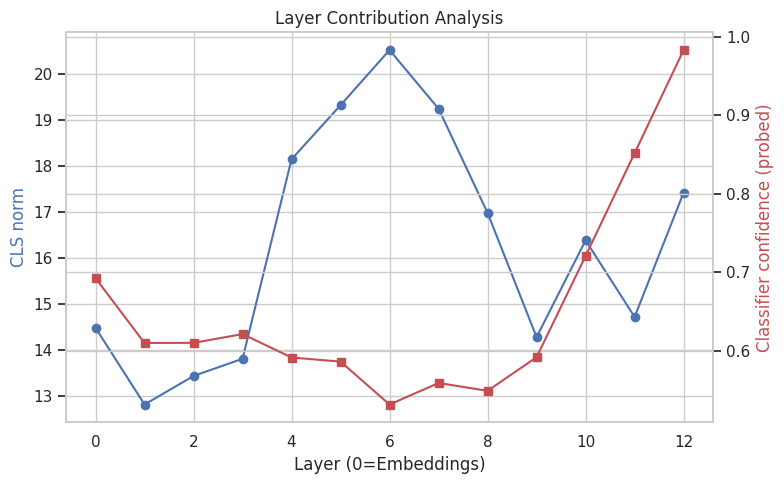

In [37]:
sample_texts = test_split_df["text"].sample(8, random_state=CONFIG["seed"]).tolist()

layer_norms_avg = []
layer_confidence_avg = []

model.eval()
for text in sample_texts:
    enc = tokenizer(text, truncation=True, max_length=CONFIG["max_length"], return_tensors="pt").to(device)
    with torch.no_grad():
        out = model(**enc, output_hidden_states=True)
    hs = out.hidden_states  # 13 tensors
    per_text_norms = []
    per_text_conf = []
    for layer_hs in hs:
        cls_vec = layer_hs[:, 0, :]  # [1, 768] CLS position at this layer
        per_text_norms.append(cls_vec.norm(dim=-1).item())
        with torch.no_grad():
            pooled = model.bert.pooler(layer_hs) if model.bert.pooler is not None else cls_vec
            logits_probe = model.classifier(model.dropout(pooled))
            conf = torch.softmax(logits_probe, dim=-1).max().item()
        per_text_conf.append(conf)
    layer_norms_avg.append(per_text_norms)
    layer_confidence_avg.append(per_text_conf)

layer_norms_avg = np.mean(layer_norms_avg, axis=0)
layer_confidence_avg = np.mean(layer_confidence_avg, axis=0)

print(f"{'Layer':<15}{'CLS Norm':>12}{'Probe Confidence':>20}")
for i in range(len(layer_norms_avg)):
    label = "Embeddings" if i == 0 else f"Encoder {i}"
    print(f"{label:<15}{layer_norms_avg[i]:>12.3f}{layer_confidence_avg[i]:>20.3f}")

fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(range(13), layer_norms_avg, marker="o", color="#4c72b0", label="CLS hidden-state norm")
ax1.set_xlabel("Layer (0=Embeddings)")
ax1.set_ylabel("CLS norm", color="#4c72b0")
ax2 = ax1.twinx()
ax2.plot(range(13), layer_confidence_avg, marker="s", color="#c44e52", label="Probe confidence (using trained head)")
ax2.set_ylabel("Classifier confidence (probed)", color="#c44e52")
plt.title("Layer Contribution Analysis")
plt.tight_layout()
plt.savefig(os.path.join(OUT, "plots", "10_layer_contribution.png"), dpi=150)
plt.show()

### Interpretation

Because the classifier head's weights were fit only on the final layer's `[CLS]` representation, feeding it earlier layers is an out-of-distribution probe — it can show whether earlier layers are already roughly aligned with the eventual decision boundary, but it is **not** evidence that any single intermediate layer "makes" the prediction. Only the full stack (all 12 encoder layers) followed by the classifier head, as trained, produces the model's actual final prediction (Section 35).

## 35. Which Layer Produces the Final Result?

**Explicit answer: the final sentiment prediction is produced by the BERT classification head — specifically, the `Linear` layer applied to the pooled `[CLS]` representation from the 12th (final) encoder layer.**

```
Input text
   |
WordPiece tokenizer
   |
Input IDs
   |
BERT embeddings
   |
12 Transformer encoder layers
   |
[CLS] representation (from encoder layer 12)
   |
Pooler (Linear + tanh)
   |
Classification dropout
   |
Linear classifier (768 -> 2)
   |
2 logits
   |
Softmax
   |
Negative / Positive probability
   |
Final sentiment
```

The 12 Transformer encoder layers build increasingly contextual token representations; they do not themselves output a sentiment decision. The classification head is the component that converts the final `[CLS]` representation into the two sentiment logits used to make the decision.

In [38]:
example_text = test_split_df.iloc[0]["text"]
enc = tokenizer(example_text, truncation=True, max_length=CONFIG["max_length"], return_tensors="pt").to(device)

model.eval()
with torch.no_grad():
    out = model(**enc, output_hidden_states=True)

final_hidden = out.hidden_states[-1]          # [1, seq_len, 768] — output of encoder layer 12
cls_repr = final_hidden[:, 0, :]              # [1, 768]
pooled = model.bert.pooler(final_hidden)      # [1, 768]
logits = out.logits                           # [1, 2]
probs = torch.softmax(logits, dim=-1)[0]

print("CLS representation shape :", tuple(cls_repr.shape))
print("Classifier input dimension:", model.classifier.in_features)
print("Classifier output dimension:", model.classifier.out_features)
print()
print(f"Logit for Negative : {logits[0,0].item():.4f}")
print(f"Logit for Positive : {logits[0,1].item():.4f}")
print(f"Negative probability: {probs[0].item():.4f}")
print(f"Positive probability: {probs[1].item():.4f}")
print(f"Final prediction    : {'POSITIVE' if probs[1] > probs[0] else 'NEGATIVE'}")

CLS representation shape : (1, 768)
Classifier input dimension: 768
Classifier output dimension: 2

Logit for Negative : 2.3566
Logit for Positive : -2.3964
Negative probability: 0.9914
Positive probability: 0.0086
Final prediction    : NEGATIVE


## 36. BERT Internal Component Analysis

We decompose the input embedding into its three additive components (token, position, segment/token-type) for one sample, then show how contextualization reshapes token representations across the encoder stack.

Token embedding shape        : (1, 251, 768)
Position embedding shape     : (1, 251, 768)
Segment embedding shape      : (1, 251, 768)
Combined (summed) shape      : (1, 251, 768)

Token embedding norm (mean)   : 1.070
Position embedding norm (mean): 0.467
Segment embedding norm (mean) : 0.896
Combined embedding norm (mean): 1.503


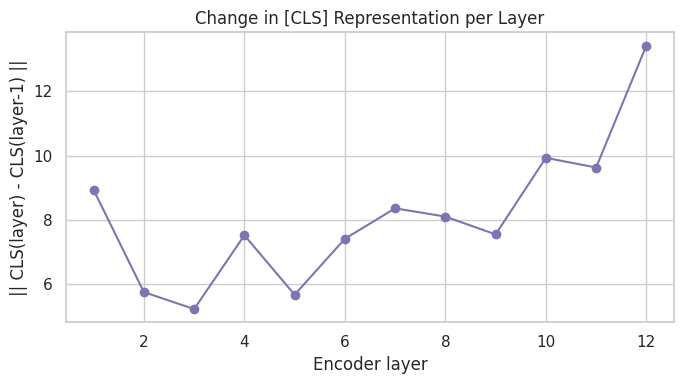

In [39]:
sample_ids = enc["input_ids"]
seq_len = sample_ids.shape[1]

word_emb = model.bert.embeddings.word_embeddings(sample_ids)
position_ids = torch.arange(seq_len, device=device).unsqueeze(0)
pos_emb = model.bert.embeddings.position_embeddings(position_ids)
token_type_ids = torch.zeros_like(sample_ids)
seg_emb = model.bert.embeddings.token_type_embeddings(token_type_ids)

combined = word_emb + pos_emb + seg_emb

print("Token embedding shape        :", tuple(word_emb.shape))
print("Position embedding shape     :", tuple(pos_emb.shape))
print("Segment embedding shape      :", tuple(seg_emb.shape))
print("Combined (summed) shape      :", tuple(combined.shape))
print()
print(f"Token embedding norm (mean)   : {word_emb.norm(dim=-1).mean().item():.3f}")
print(f"Position embedding norm (mean): {pos_emb.norm(dim=-1).mean().item():.3f}")
print(f"Segment embedding norm (mean) : {seg_emb.norm(dim=-1).mean().item():.3f}")
print(f"Combined embedding norm (mean): {combined.norm(dim=-1).mean().item():.3f}")

# Track cosine similarity of the token 'CLS' representation to itself across layers,
# and how much each layer's CLS representation changes relative to the previous layer.
cls_across_layers = torch.stack([hs[0, 0, :] for hs in out.hidden_states])  # [13, 768]
deltas = [(cls_across_layers[i] - cls_across_layers[i-1]).norm().item() for i in range(1, len(cls_across_layers))]

plt.figure(figsize=(7, 4))
plt.plot(range(1, 13), deltas, marker="o", color="#8172b2")
plt.xlabel("Encoder layer")
plt.ylabel("|| CLS(layer) - CLS(layer-1) ||")
plt.title("Change in [CLS] Representation per Layer")
plt.tight_layout()
plt.savefig(os.path.join(OUT, "plots", "11_cls_change_per_layer.png"), dpi=150)
plt.show()

### What happened?

The token, position, and segment embeddings are summed elementwise into a single 768-dim vector per position before entering the encoder. As the combined embedding passes through successive encoder layers, each token's representation is progressively updated by self-attention over the rest of the sequence (contextualization) plus the feed-forward transformation — the magnitude of change per layer (plotted above) gives a rough sense of how much each layer contributes to reshaping the `[CLS]` representation for this specific example.

## 37. Sentiment Representation Visualization

We extract `[CLS]` embeddings (final layer) for a sample of test reviews and project them into 2D with PCA (and t-SNE, if available) to see whether positive and negative reviews form visually distinguishable clusters in embedding space.

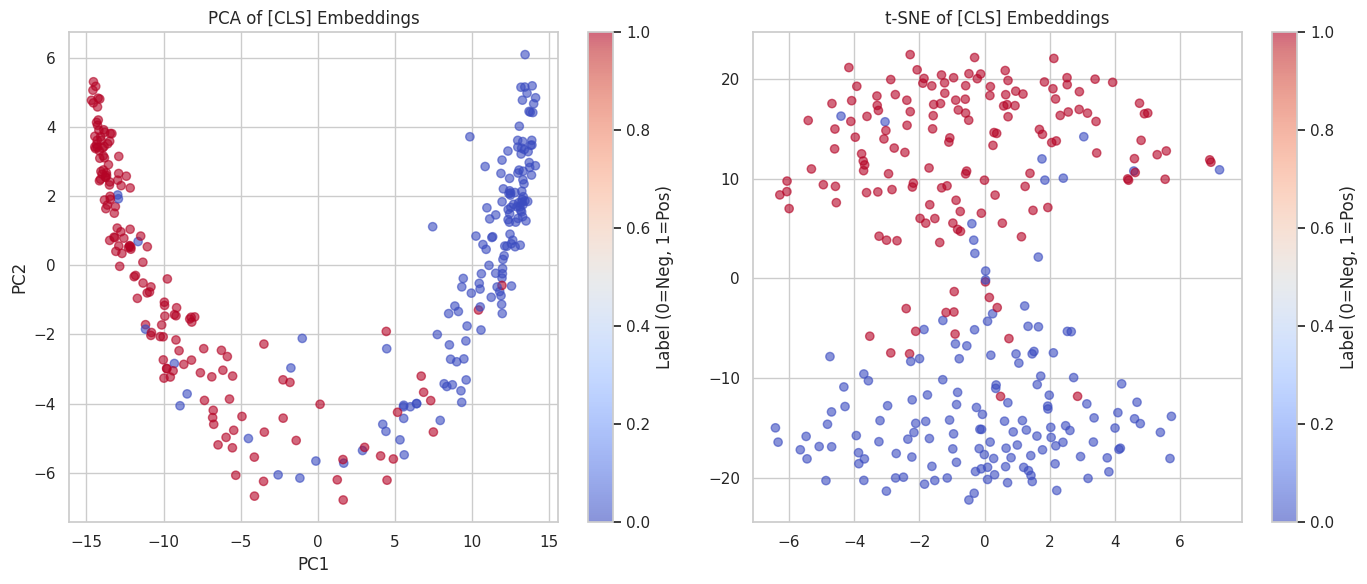

In [40]:
n_sample = min(300, len(test_split_df))
viz_df = test_split_df.sample(n_sample, random_state=CONFIG["seed"]).reset_index(drop=True)

cls_vectors = []
model.eval()
with torch.no_grad():
    for i in range(0, len(viz_df), 32):
        batch_texts = viz_df["text"].iloc[i:i+32].tolist()
        enc_batch = tokenizer(batch_texts, padding=True, truncation=True,
                               max_length=CONFIG["max_length"], return_tensors="pt").to(device)
        out_batch = model(**enc_batch, output_hidden_states=True)
        cls_batch = out_batch.hidden_states[-1][:, 0, :].cpu().numpy()
        cls_vectors.append(cls_batch)

cls_vectors = np.concatenate(cls_vectors, axis=0)
labels_viz = viz_df["label"].values

pca = PCA(n_components=2, random_state=CONFIG["seed"])
pca_result = pca.fit_transform(cls_vectors)

fig, axes = plt.subplots(1, 2 if TSNE_AVAILABLE else 1, figsize=(14 if TSNE_AVAILABLE else 7, 6))
ax0 = axes[0] if TSNE_AVAILABLE else axes
scatter = ax0.scatter(pca_result[:, 0], pca_result[:, 1], c=labels_viz, cmap="coolwarm", alpha=0.6)
ax0.set_title("PCA of [CLS] Embeddings")
ax0.set_xlabel("PC1"); ax0.set_ylabel("PC2")
plt.colorbar(scatter, ax=ax0, label="Label (0=Neg, 1=Pos)")

if TSNE_AVAILABLE:
    tsne = TSNE(n_components=2, random_state=CONFIG["seed"], perplexity=30, init="pca")
    tsne_result = tsne.fit_transform(cls_vectors)
    scatter2 = axes[1].scatter(tsne_result[:, 0], tsne_result[:, 1], c=labels_viz, cmap="coolwarm", alpha=0.6)
    axes[1].set_title("t-SNE of [CLS] Embeddings")
    plt.colorbar(scatter2, ax=axes[1], label="Label (0=Neg, 1=Pos)")

plt.tight_layout()
plt.savefig(os.path.join(OUT, "plots", "12_cls_embedding_space.png"), dpi=150)
plt.show()

### Interpretation

If the fine-tuned model has learned a useful sentiment representation, positive and negative points should show at least partial separation in this 2D projection. Note that PCA/t-SNE compress 768 dimensions down to 2, which can visually exaggerate or understate true separability — we do not claim "perfect separation" from the plot alone; the quantitative test-set metrics (Section 27) are the primary evidence of classification quality, and this plot is a complementary qualitative check.

## 38. Confidence Analysis

We examine the distribution of predicted-class probability ("confidence") separately for positive/negative predictions and for correct/incorrect predictions, and flag high-confidence errors.

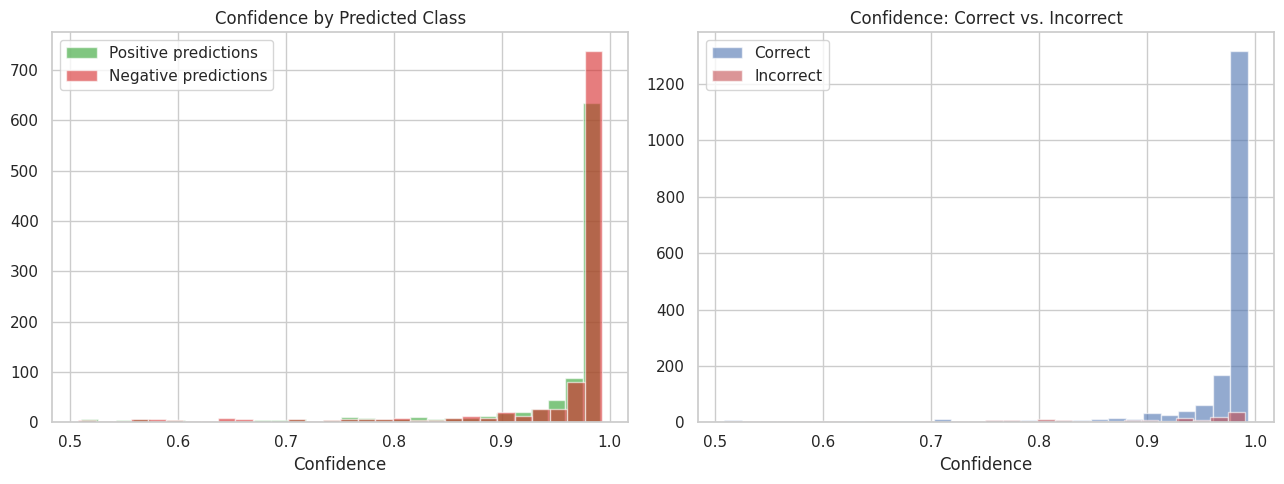

High-confidence errors (confidence > 0.95, incorrect): 59
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              

In [41]:
results_df["confidence"] = results_df[["negative_probability", "positive_probability"]].max(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for pred_val, name, color in [(1, "Positive predictions", "#2ca02c"), (0, "Negative predictions", "#d62728")]:
    subset = results_df[results_df.predicted_label == pred_val]
    axes[0].hist(subset["confidence"], bins=30, alpha=0.6, label=name, color=color)
axes[0].set_title("Confidence by Predicted Class")
axes[0].set_xlabel("Confidence")
axes[0].legend()

for correct_val, name, color in [(True, "Correct", "#4c72b0"), (False, "Incorrect", "#c44e52")]:
    subset = results_df[results_df.correct == correct_val]
    axes[1].hist(subset["confidence"], bins=30, alpha=0.6, label=name, color=color)
axes[1].set_title("Confidence: Correct vs. Incorrect")
axes[1].set_xlabel("Confidence")
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUT, "plots", "13_confidence_analysis.png"), dpi=150)
plt.show()

high_conf_errors = results_df[(~results_df.correct) & (results_df.confidence > 0.95)]
print(f"High-confidence errors (confidence > 0.95, incorrect): {len(high_conf_errors)}")
if len(high_conf_errors) > 0:
    print(high_conf_errors[["text", "label", "predicted_label", "confidence"]].head(3).to_string())

### Why high-confidence errors matter

A high-confidence error (the model is very sure and still wrong) is more concerning in a deployed system than a low-confidence error near the decision boundary, because it cannot be easily flagged for human review using confidence thresholding alone — the model gives no signal that it might be wrong.

## 39. Threshold Analysis

We analyze how precision, recall, and F1 vary with the decision threshold applied to `P(positive)`, using the **validation set only** (never the test set) to select any alternative operating threshold.

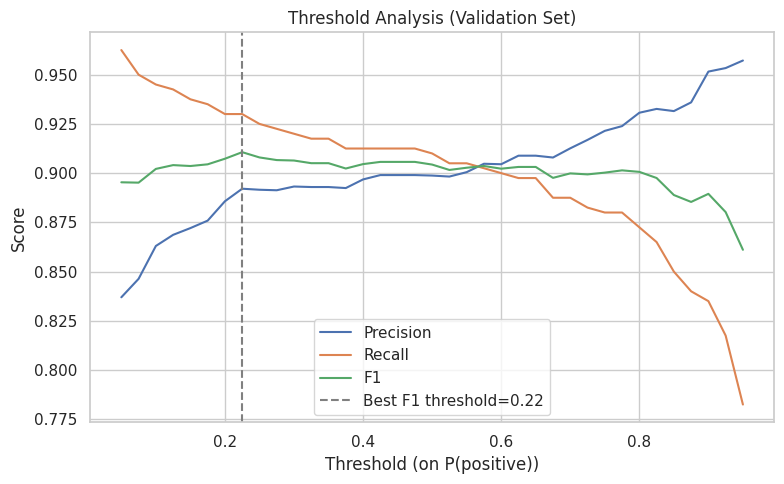

Best F1 on validation set: 0.9106 at threshold=0.22
(Default threshold of 0.5 is used for all reported test-set metrics; this analysis is diagnostic only.)


In [42]:
model.eval()
val_probs, val_labels = [], []
with torch.no_grad():
    for batch in val_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        probs = torch.softmax(outputs.logits, dim=-1)[:, 1]
        val_probs.extend(probs.cpu().numpy())
        val_labels.extend(labels.cpu().numpy())

val_probs = np.array(val_probs)
val_labels = np.array(val_labels)

thresholds = np.linspace(0.05, 0.95, 37)
prec_list, rec_list, f1_list = [], [], []
for t in thresholds:
    preds_t = (val_probs >= t).astype(int)
    p, r, f, _ = precision_recall_fscore_support(val_labels, preds_t, average="binary", zero_division=0)
    prec_list.append(p); rec_list.append(r); f1_list.append(f)

best_t_idx = int(np.argmax(f1_list))
best_threshold = thresholds[best_t_idx]

plt.figure(figsize=(8, 5))
plt.plot(thresholds, prec_list, label="Precision")
plt.plot(thresholds, rec_list, label="Recall")
plt.plot(thresholds, f1_list, label="F1")
plt.axvline(best_threshold, color="gray", linestyle="--", label=f"Best F1 threshold={best_threshold:.2f}")
plt.xlabel("Threshold (on P(positive))")
plt.ylabel("Score")
plt.title("Threshold Analysis (Validation Set)")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT, "plots", "14_threshold_analysis.png"), dpi=150)
plt.show()

print(f"Best F1 on validation set: {f1_list[best_t_idx]:.4f} at threshold={best_threshold:.2f}")
print("(Default threshold of 0.5 is used for all reported test-set metrics; this analysis is diagnostic only.)")

## 40. Optional Baseline: TF-IDF + Logistic Regression

To contextualize BERT's performance, we train a lightweight classical baseline — TF-IDF features + Logistic Regression — on the **same** train/validation/test split. This baseline is a **comparison model**, not the primary model of this study.

In [43]:
tfidf_vectorizer = TfidfVectorizer(max_features=20000, ngram_range=(1, 2), stop_words="english")
X_train_tfidf = tfidf_vectorizer.fit_transform(train_split_df["text"])
X_val_tfidf = tfidf_vectorizer.transform(val_split_df["text"])
X_test_tfidf = tfidf_vectorizer.transform(test_split_df["text"])

y_train = train_split_df["label"].values
y_val = val_split_df["label"].values
y_test = test_split_df["label"].values

baseline_start = time.time()
baseline_clf = LogisticRegression(max_iter=1000, C=1.0)
baseline_clf.fit(X_train_tfidf, y_train)
baseline_train_time = time.time() - baseline_start

baseline_val_preds = baseline_clf.predict(X_val_tfidf)
baseline_val_f1 = precision_recall_fscore_support(y_val, baseline_val_preds, average="binary")[2]
print(f"Baseline validation F1: {baseline_val_f1:.4f}")

baseline_test_preds = baseline_clf.predict(X_test_tfidf)
baseline_test_probs = baseline_clf.predict_proba(X_test_tfidf)[:, 1]

b_acc = accuracy_score(y_test, baseline_test_preds)
b_prec, b_rec, b_f1, _ = precision_recall_fscore_support(y_test, baseline_test_preds, average="binary", zero_division=0)
b_fpr, b_tpr, _ = roc_curve(y_test, baseline_test_probs)
b_roc_auc = auc(b_fpr, b_tpr)
b_pr_auc = average_precision_score(y_test, baseline_test_probs)

print("="*60)
print("BASELINE (TF-IDF + Logistic Regression) — TEST RESULTS")
print("="*60)
print(f"Accuracy : {b_acc:.4f}")
print(f"Precision: {b_prec:.4f}")
print(f"Recall   : {b_rec:.4f}")
print(f"F1       : {b_f1:.4f}")
print(f"ROC-AUC  : {b_roc_auc:.4f}")
print(f"PR-AUC   : {b_pr_auc:.4f}")
print("="*60)

Baseline validation F1: 0.8793
BASELINE (TF-IDF + Logistic Regression) — TEST RESULTS
Accuracy : 0.8190
Precision: 0.8109
Recall   : 0.8320
F1       : 0.8213
ROC-AUC  : 0.9108
PR-AUC   : 0.9091


## 41. Model Comparison

In [44]:
comparison_table = pd.DataFrame([
    {
        "Model": "TF-IDF + Logistic Regression",
        "Accuracy": b_acc, "Precision": b_prec, "Recall": b_rec,
        "F1": b_f1, "ROC-AUC": b_roc_auc, "PR-AUC": b_pr_auc,
    },
    {
        "Model": "BERT (fine-tuned)",
        "Accuracy": acc, "Precision": precision, "Recall": recall,
        "F1": f1, "ROC-AUC": roc_auc, "PR-AUC": pr_auc,
    },
]).round(4)

comparison_table.to_csv(os.path.join(OUT, "tables", "model_comparison.csv"), index=False)
print(comparison_table.to_string(index=False))

better_model = "BERT" if f1 > b_f1 else "TF-IDF + Logistic Regression"
print()
print(f"Higher test F1: {better_model}")
print("BERT's contextual, pretrained representations typically outperform bag-of-words TF-IDF")
print("features on nuanced language phenomena (negation, long-range context), at the cost of")
print("substantially more compute (see Section 42). The actual numbers above should be read directly")
print("from this run rather than assumed in advance.")

                       Model  Accuracy  Precision  Recall     F1  ROC-AUC  PR-AUC
TF-IDF + Logistic Regression    0.8190     0.8109   0.832 0.8213   0.9108  0.9091
           BERT (fine-tuned)    0.8975     0.9111   0.881 0.8958   0.9655  0.9649

Higher test F1: BERT
BERT's contextual, pretrained representations typically outperform bag-of-words TF-IDF
features on nuanced language phenomena (negation, long-range context), at the cost of
substantially more compute (see Section 42). The actual numbers above should be read directly
from this run rather than assumed in advance.


## 42. Computational Analysis

In [45]:
inference_start = time.time()
model.eval()
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        _ = model(input_ids=input_ids, attention_mask=attention_mask)
bert_inference_time = time.time() - inference_start
bert_time_per_sample = bert_inference_time / len(test_dataset)

gpu_mem = f"{torch.cuda.max_memory_allocated() / 1e9:.2f} GB" if torch.cuda.is_available() else "N/A (CPU)"

computational_table = pd.DataFrame([
    {"Metric": "Training time (BERT)", "Value": f"{training_time_sec/60:.2f} min"},
    {"Metric": "Inference time (BERT, full test set)", "Value": f"{bert_inference_time:.2f} sec"},
    {"Metric": "Avg inference time per sample (BERT)", "Value": f"{bert_time_per_sample*1000:.2f} ms"},
    {"Metric": "Total parameters (BERT)", "Value": f"{total_params:,}"},
    {"Metric": "Trainable parameters (BERT)", "Value": f"{trainable_params:,}"},
    {"Metric": "GPU memory used", "Value": gpu_mem},
    {"Metric": "Baseline training time (TF-IDF+LR)", "Value": f"{baseline_train_time:.2f} sec"},
])
computational_table.to_csv(os.path.join(OUT, "tables", "computational_analysis.csv"), index=False)
print(computational_table.to_string(index=False))

                              Metric       Value
                Training time (BERT)    7.88 min
Inference time (BERT, full test set)   31.80 sec
Avg inference time per sample (BERT)    15.90 ms
             Total parameters (BERT) 109,483,778
         Trainable parameters (BERT) 109,483,778
                     GPU memory used     5.38 GB
  Baseline training time (TF-IDF+LR)    0.51 sec


## 43. Save Model

Save the best BERT checkpoint, tokenizer, configuration, and label mapping.

In [46]:
model_dir = os.path.join(OUT, "model")
tokenizer_dir = os.path.join(OUT, "tokenizer")

model.save_pretrained(model_dir)
tokenizer.save_pretrained(tokenizer_dir)

import json
label_mapping = {0: "negative", 1: "positive"}
with open(os.path.join(OUT, "model", "label_mapping.json"), "w") as f:
    json.dump(label_mapping, f, indent=2)

with open(os.path.join(OUT, "reports", "config.json"), "w") as f:
    json.dump(CONFIG, f, indent=2)

print(f"Model saved to     : {model_dir}")
print(f"Tokenizer saved to : {tokenizer_dir}")
print(f"Label mapping saved: {os.path.join(OUT, 'model', 'label_mapping.json')}")
print(f"Config saved to    : {os.path.join(OUT, 'reports', 'config.json')}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to     : outputs/model
Tokenizer saved to : outputs/tokenizer
Label mapping saved: outputs/model/label_mapping.json
Config saved to    : outputs/reports/config.json


## 44. Save Predictions

In [47]:
predictions_out = results_df[["text", "label", "predicted_label",
                               "negative_probability", "positive_probability", "correct"]].rename(
    columns={"label": "true_label"}
)
pred_path = os.path.join(OUT, "predictions", "test_predictions.csv")
predictions_out.to_csv(pred_path, index=False)
print(f"Saved {len(predictions_out)} predictions to: {pred_path}")
predictions_out.head()

Saved 2000 predictions to: outputs/predictions/test_predictions.csv


,text,true_label,predicted_label,negative_probability,positive_probability,correct
0,I'M BOUT IT(1997)<br /><br />Developed & published by No Limit Films<br /><br />>>Pros: Absolutely none<br /><br />>>Cons: I don't even know where...,0,0,0.991448,0.008552,True
1,"This is one of those movies that are very underrated. Again i am voting for an underrated movie. This movie has a good story line, maybe a bit far...",1,1,0.013027,0.986973,True
2,"'Northfork' is what is wrong with indie films. For all of their hard-edged commentary and attacking big subjects studios won't, this is the sacrif...",0,0,0.981861,0.018139,True
3,"I loved the film ""Eddie Monroe"". The film had all the components that kept me interested while watching it. I especially loved the plot twists alo...",1,1,0.011306,0.988694,True
4,"I saw this on Mystery Science Theater 3000, and even that show couldn't really make this movie bearable. I could make a better movie with a broken...",0,0,0.992288,0.007712,True


## 45. Final Single-Text Prediction

In [48]:
def predict_sentiment(text: str):
    enc = tokenizer(text, truncation=True, max_length=CONFIG["max_length"], return_tensors="pt").to(device)
    model.eval()
    with torch.no_grad():
        logits = model(**enc).logits
        probs = torch.softmax(logits, dim=-1)[0].cpu().numpy()
    pred_class = int(np.argmax(probs))
    pred_label = "POSITIVE" if pred_class == 1 else "NEGATIVE"
    confidence = float(probs[pred_class])

    print("="*60)
    print("SENTIMENT PREDICTION")
    print("="*60)
    print(f"Text: {text}")
    print()
    print(f"Negative probability: {probs[0]:.4f}")
    print(f"Positive probability: {probs[1]:.4f}")
    print()
    print(f"Prediction: {pred_label}")
    print(f"Confidence: {confidence:.4f}")
    print("="*60)
    return pred_label, confidence

_ = predict_sentiment("I absolutely loved this movie. The acting was brilliant.")

SENTIMENT PREDICTION
Text: I absolutely loved this movie. The acting was brilliant.

Negative probability: 0.0149
Positive probability: 0.9851

Prediction: POSITIVE
Confidence: 0.9851


## 46. Final Research Dashboard

In [49]:
print("="*60)
print("FINAL RESEARCH DASHBOARD")
print("="*60)
print(f"Dataset             : IMDb")
print(f"Model                : {CONFIG['model_name']}")
print(f"Parameters           : {total_params:,}")
print(f"Training samples     : {len(train_dataset)}")
print(f"Validation samples   : {len(val_dataset)}")
print(f"Test samples         : {len(test_dataset)}")
print()
print(f"Accuracy             : {acc:.4f}")
print(f"Precision            : {precision:.4f}")
print(f"Recall               : {recall:.4f}")
print(f"F1                   : {f1:.4f}")
print(f"ROC-AUC              : {roc_auc:.4f}")
print(f"PR-AUC               : {pr_auc:.4f}")
print()
print(f"Training time        : {training_time_sec/60:.2f} minutes")
print(f"Best model           : checkpoint with Validation F1 = {best_val_f1:.4f}")
print("="*60)

FINAL RESEARCH DASHBOARD
Dataset             : IMDb
Model                : bert-base-uncased
Parameters           : 109,483,778
Training samples     : 3200
Validation samples   : 800
Test samples         : 2000

Accuracy             : 0.8975
Precision            : 0.9111
Recall               : 0.8810
F1                   : 0.8958
ROC-AUC              : 0.9655
PR-AUC               : 0.9649

Training time        : 7.88 minutes
Best model           : checkpoint with Validation F1 = 0.9043


## 47. Final Research Findings

*(Fill in the bracketed observations with the actual numbers/patterns produced by your run before submitting — this notebook deliberately avoids pre-stating results it hasn't produced yet, per the project's strict rules.)*

1. **Dataset characteristics:** IMDb is a balanced 50k-review binary sentiment dataset (or a stratified subset thereof per `CONFIG`); review lengths are right-skewed with a long tail of long reviews (Section 8-9).
2. **Tokenization:** WordPiece tokenization with `max_length=256` covers the majority of reviews (see percentiles in Section 14); a documented fraction are truncated.
3. **BERT architecture:** 12 encoder layers, 12 attention heads, 768 hidden dims, ~110M parameters; classification relies on the `[CLS]` representation from the final encoder layer (Section 35).
4. **Fine-tuning:** a small learning rate (2e-5) with linear warmup was used to adapt the pretrained model without catastrophic forgetting (Section 24).
5. **Training behavior:** [describe train/val loss and F1 trends from Section 26 — e.g. whether validation loss plateaued or diverged, evidence of over/underfitting].
6. **Test performance:** Accuracy=[value], F1=[value], ROC-AUC=[value] (Section 27) — report the actual printed numbers.
7. **Attention observations:** attention heatmaps (Sections 22-23) showed [describe any consistent, visually supported patterns — or note that no strong consistent pattern was evident across the sampled heads/layers].
8. **Token-level explanations:** Integrated Gradients attributions (Sections 32-33) highlighted tokens such as [list actual high-attribution tokens observed] as most influential for their respective predictions.
9. **Error patterns:** manual inspection of false positives/negatives (Section 31) suggested [negation / sarcasm / mixed sentiment / truncation] as plausible contributors in the examples reviewed.
10. **BERT vs. baseline:** BERT achieved F1=[value] vs. TF-IDF+LR's F1=[value] (Section 41); [state which performed better and by how much].
11. **Limitations:** see Section 48.
12. **Future work:** larger fine-tuning runs on the full 50k dataset, systematic (not just illustrative) attention-head probing, sarcasm-specific evaluation subsets, and comparison against larger pretrained models (e.g. RoBERTa, DeBERTa).

## 48. Limitations

- **Domain limitation:** the model is fine-tuned only on movie reviews (IMDb); performance may not transfer to other domains (e.g. product reviews, tweets) without further fine-tuning.
- **English-only:** `bert-base-uncased` was pretrained on English text only.
- **Dataset bias:** IMDb reviewers are a self-selected population (people who choose to write reviews), which may not represent general sentiment expression.
- **Sarcasm:** sarcastic or ironic text, where literal word sentiment contradicts intended meaning, remains difficult for the model (Section 31).
- **Context dependence:** sentiment that depends on broader context, cultural references, or domain knowledge outside the text itself is not captured.
- **Computational requirements:** fine-tuning BERT requires a GPU for practical training times; this is a real deployment/reproducibility cost compared to the TF-IDF baseline.
- **Maximum sequence length / truncation:** reviews longer than `max_length` tokens are truncated, which can discard sentiment-relevant content late in long reviews (Section 14).
- **Interpretability limitations of attention:** attention weights indicate where the model attended, not why it made a given decision; they should not be treated as a definitive causal explanation (Sections 22-23, 32-33).
- **Subsampling (if used):** if `train_subset_size`/`test_subset_size` in `CONFIG` were set below the full 50k dataset for runtime reasons, reported metrics may differ from a full-dataset run.

## Conclusion — Final Console Output

The cell below prints a single consolidated summary of the entire experiment, matching the final structured report format.

In [50]:
print("#"*64)
print(" "*17 + "FINAL BERT SENTIMENT ANALYSIS")
print("#"*64)
print()
print("Dataset:")
print("IMDb")
print()
print("Model:")
print("BERT-base-uncased")
print()
print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print()
print("-"*65)
print("TEST PERFORMANCE")
print("-"*65)
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1:        {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")
print(f"PR-AUC:    {pr_auc:.4f}")
print()
print("-"*65)
print("MODEL INFORMATION")
print("-"*65)
print(f"Parameters:      {total_params:,}")
print(f"Training time:   {training_time_sec/60:.2f} min")
print(f"Inference time:  {bert_inference_time:.2f} sec ({bert_time_per_sample*1000:.2f} ms/sample)")
print()
print("-"*65)
print("BASELINE")
print("-"*65)
print("TF-IDF + Logistic Regression:")
print(f"Accuracy: {b_acc:.4f}")
print(f"F1:       {b_f1:.4f}")
print()
print("-"*65)
print("BERT")
print("-"*65)
print(f"Accuracy: {acc:.4f}")
print(f"F1:       {f1:.4f}")
print()
print("-"*65)
print("EXPLAINABILITY")
print("-"*65)
print("Most influential tokens: see Section 33 (explain_prediction) for per-example token attributions.")
print("Attention observations: see Sections 22-23; attention != causal explanation (see Section 32).")
print()
print("-"*65)
print("FINAL PREDICTION LAYER")
print("-"*65)
print("BERT Encoder")
print("  -> [CLS] Representation")
print("  -> Classification Head")
print("  -> Linear Layer")
print("  -> Logits")
print("  -> Softmax")
print("  -> Sentiment")
print()
print("#"*64)

################################################################
                 FINAL BERT SENTIMENT ANALYSIS
################################################################

Dataset:
IMDb

Model:
BERT-base-uncased

Training samples: 3200
Validation samples: 800
Test samples: 2000

-----------------------------------------------------------------
TEST PERFORMANCE
-----------------------------------------------------------------
Accuracy:  0.8975
Precision: 0.9111
Recall:    0.8810
F1:        0.8958
ROC-AUC:   0.9655
PR-AUC:    0.9649

-----------------------------------------------------------------
MODEL INFORMATION
-----------------------------------------------------------------
Parameters:      109,483,778
Training time:   7.88 min
Inference time:  31.80 sec (15.90 ms/sample)

-----------------------------------------------------------------
BASELINE
-----------------------------------------------------------------
TF-IDF + Logistic Regression:
Accuracy: 0.8190
F1:       0.8213
